## Maintance Prediction 

<img src="https://img.freepik.com/free-vector/maintenance-background-design_1294-45.jpg?semt=ais_hybrid" alt="My Image">

## Table of Contents 

<div style="border: 2px solid red; padding: 10px; background-color: #F5F5F5; color: black; border-radius: 30px 45px 30px 45px;">

   
    
    
<p> &bull;        <a target="_blank"> Introudction</a>  </p> 

<p> &bull;      <a target="_blank"> Explanory Data Analysis</a>  </p>

<p>&bull;       <a target="_blank"> Data Processing</a>  </p>

<p>&bull;       <a target="_blank"> Model Bulding</a> </p>   
    
<p>&bull;       <a target="_blank"> Evalution Metrics </a> </p> 

<p>&bull;       <a target="_blank"> Results & see the best models </a> </p>   

</div>

## Data Information

<div style="border: 2px solid red; padding: 10px; background-color: #F5F5F5; color: black; border-radius: 30px 45px 30px 45px;">


<p>&bull; Machine Predictive Maintenance Classification Dataset <p>

<p>&bull; Since real predictive maintenance datasets are generally difficult to obtain and in particular difficult to publish, we present and provide a synthetic dataset that reflects real predictive maintenance encountered in the industry to the best of our knowledge.</p>

<p>&bull;Additional Information :

The dataset consists of 10 000 data points stored as rows with 14 features in columns.</p>

<p>&bull;Important : There are two Targets - Do not make the mistake of using one of them as feature, as it will lead to leakage.</p>

<p>&bull; Target : Failure or Not</p>

<p>&bull; Failure Type : Type of Failure</p>

<p>&bull; <a href="https://archive.ics.uci.edu/ml/datasets/AI4I+2020+Predictive+Maintenance+Dataset" target="_blank">Data Source UCI :</a></p>


</div>

![](https://j.gifs.com/76kDrQ.gif)

## Understand the problem :








<div style="border: 2px solid red; padding: 10px; background-color: #F5F5F5; color: black; border-radius: 30px 45px 30px 45px;">

<p> &bull; This problem Consider as binary Classification problrm   .</p> 

<p> &bull; Target of this problem to predict on  Target Column and classify if Failure or Not   .</p> 


<p> &bull; I will Train 5 models for Machine learning with visualization of them. (SportVectorMachine,RandomForestClassifier,Decision Tree Classifier,gradient boosting classifier,LogisticRegression .</p> 

<p>&bull; Also i will Make Explanory Analysis for the Data By using both SQL & Pandas  </p>

<p>&bull; Also i will learn the Relations between the Feature to  Make Different Plots that Represent the Data  </p>   
    
</div>

| Data fields              | Description                                                                                                                                       |
|---------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------|
| UID:                      | identificador único con valores entre 1 y 10000                                                                                                   |
| productID:                | compuesto por una letra L, M o H para variantes de calidad baja (50 % de todos los productos), media (30 %) y alta (20 %), junto con un número de serie específico de la variante |
| air temperature [K]:      | generada utilizando un proceso de caminata aleatoria, posteriormente normalizado a una desviación estándar de 2 K alrededor de 300 K            |
| Temperature               | temperatura en grados Celsius                                                                                                                     |
| process temperature [K]:  | generada utilizando un proceso de caminata aleatoria normalizado a una desviación estándar de 1 K, sumada a la temperatura del aire más 10 K   |
| rotational speed [rpm]:   | calculada a partir de una potencia de 2860 W, superpuesta con un ruido distribuido normalmente                                                   |
| torque [Nm]:              | los valores de torque se distribuyen normalmente alrededor de 40 Nm con una σ = 10 Nm y sin valores negativos                                   |
| tool wear [min]:          | Las variantes de calidad H/M/L agregan 5/3/2 minutos de desgaste de herramienta a la herramienta utilizada en el proceso                        |
| machine failure:          | etiqueta que indica si la máquina ha fallado en este punto de datos particular cuando alguno de los siguientes modos de falla es verdadero      |

## imports 

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import graphviz
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder,MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.datasets import make_classification
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.metrics import classification_report,confusion_matrix ,ConfusionMatrixDisplay,accuracy_score,precision_score,recall_score,f1_score
from sklearn.metrics import mean_squared_error
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
import sqlite3
from plotly.graph_objs import *
import plotly.express as px 
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.pipeline import Pipeline
import warnings

# Suppress all warnings
warnings.filterwarnings('ignore')



In [76]:
# load the data:

data=pd.read_csv("../data/ai4i2020.csv")
data.head(25)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,0,0,0,0,0
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,0,0,0,0,0
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,0,0,0,0,0
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,0,0,0,0,0
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,0,0,0,0,0


In [8]:
data['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

## Explore the Data :

In [9]:
#Default theme

plt.style.use('dark_background')
warnings.filterwarnings("ignore", category=UserWarning, message="findfont: Font family")


In [11]:
#get info about the dataset:
print(data.info())
print("-"*25)
# to know more about the shape of the dataset:
print("Tamaño del dataset -->>",data.shape)
print("Size of the dataset -->>",data.size,"Record")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [12]:
#get the statistical:

data.describe().T.style.background_gradient(cmap="Dark2")

,count,mean,std,min,25%,50%,75%,max
UDI,10000.000000,5000.500000,2886.895680,1.000000,2500.750000,5000.500000,7500.250000,10000.000000
Air temperature [K],10000.000000,300.004930,2.000259,295.300000,298.300000,300.100000,301.500000,304.500000
Process temperature [K],10000.000000,310.005560,1.483734,305.700000,308.800000,310.100000,311.100000,313.800000
Rotational speed [rpm],10000.000000,1538.776100,179.284096,1168.000000,1423.000000,1503.000000,1612.000000,2886.000000
Torque [Nm],10000.000000,39.986910,9.968934,3.800000,33.200000,40.100000,46.800000,76.600000
Tool wear [min],10000.000000,107.951000,63.654147,0.000000,53.000000,108.000000,162.000000,253.000000
Machine failure,10000.000000,0.033900,0.180981,0.000000,0.000000,0.000000,0.000000,1.000000
TWF,10000.000000,0.004600,0.067671,0.000000,0.000000,0.000000,0.000000,1.000000
HDF,10000.000000,0.011500,0.106625,0.000000,0.000000,0.000000,0.000000,1.000000
PWF,10000.000000,0.009500,0.097009,0.000000,0.000000,0.000000,0.000000,1.000000


In [13]:
# get Types of features:

data.dtypes

UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [20]:
cols = list(data.columns)

cols.remove('UDI')
cols.remove('Product ID')

print(cols)
# Create a dictionary to store the unique values for each column
unique_values = {}

# Iterate over the columns and store the unique values in the dictionary
for col in cols:
    unique_values[col] = data[col].unique()

# Convert the dictionary to a dataframe
unique_values_data = pd.DataFrame.from_dict(unique_values, orient='index').transpose()

# Print the dataframe
unique_values_data.head(32)

['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,1,1,1,1,1,1
2,H,298.3,308.5,1498,49.4,5,None,None,None,None,None,None
3,NaN,298.5,309.0,1433.0,39.5,7.0,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,298.4,308.9,1425.0,40.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,298.6,309.1,1558.0,41.9,11.0,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,298.7,309.2,1527.0,42.4,14.0,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,298.8,309.3,1667.0,40.2,16.0,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,298.9,309.4,1741.0,28.6,18.0,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,299.0,309.5,1782.0,28.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN


## Limpieza :

<div style="border: 3px solid yellow; padding: 10px; background-color: #F5F5F5; color: black; border-radius: 30px 45px 30px 45px;">

<p> &bull; Primero verifiqué si existían valores nulos. </p> 

<p> &bull; También eliminé columnas innecesarias como UDI y Product ID. </p>

<p> &bull; Revisé valores duplicados y los eliminé si existían. </p>

<p> &bull; Eliminé valores nulos estructurales como las unidades en las columnas. </p>

<p> &bull; Utilicé el método Simple Imputer para completar los valores nulos cuando la cantidad era muy grande. </p> 

<p> &bull; Utilicé la estrategia de la mediana para las variables numéricas. </p> 

<p> &bull; Realicé un reshape y posteriormente apliqué squeeze sobre los datos. </p>

<p> &bull; Cualquier columna cuyo porcentaje de valores faltantes superara el 75 % fue eliminada. </p>

</div>

In [21]:
# check the Null Values :
# ok there no Any Null values :

data.isna().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [22]:
# Drop any null values if found :
df = data.dropna()
df.isna().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [40]:
data.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')

In [25]:
# Drop unless column like UDI & Product ID :

df = data.drop(columns=["UDI", "Product ID"])
df.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')

In [26]:
# Check if there are aduplicated values in the data & drop it if found :
duplicated_features=df.duplicated().sum()
print("Number of duplicates ----->>> ",duplicated_features)
df = df.drop_duplicates()
duplicated_features=df.duplicated().sum()
print("Number of duplicates of cleaning it ----->>> ",duplicated_features)

Number of duplicates ----->>>  0
Number of duplicates of cleaning it ----->>>  0


## Ingeniería de Características :

<div style="border: 3px solid yellow; padding: 10px; background-color: #F5F5F5; color: black; border-radius: 30px 45px 30px 45px;">

<p> &bull; Primero: conversión de temperatura de Kelvin a grados centígrados [1 K = -272.15 °C]. </p> 

<p> &bull; Renombramiento de la temperatura en grados centígrados (°C) a partir de Kelvin (K). </p>

<p> &bull; Creación de una nueva característica llamada diferencia de temperatura: temperatura del proceso [°C] - temperatura del aire [°C]. </p>

</div>

In [27]:

df["Air temperature [K]"] = df["Air temperature [K]"] - 272.15
df["Process temperature [K]"] = df["Process temperature [K]"] - 272.15

# Renaming temperature in Centigrate(°C) from Kelvin (K)

df.rename(columns={"Air temperature [K]" : "Air temperature [°C]","Process temperature [K]" : "Process temperature [°C]"},inplace=True)
print(df.columns)

Index(['Type', 'Air temperature [°C]', 'Process temperature [°C]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')


In [28]:
# Remove units and other elements from column headers
df = df.rename(columns={
    'Air temperature [°C]': 'Air_temperature',
    'Process temperature [°C]': 'Process_temperature ',
    'Rotational speed [rpm]': 'Rotational_speed',
    'Torque [Nm]':'Torque',
    'Tool wear [min]':'Tool_wear',
    'Solar Radiation (MJ/m2)':'Solar_Radiation',
    'Failure Type': 'Failure_Type'
    })

df.head(10)

,Type,Air_temperature,Process_temperature,Rotational_speed,Torque,Tool_wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,25.95,36.45,1551,42.8,0,0,0,0,0,0,0
1,L,26.05,36.55,1408,46.3,3,0,0,0,0,0,0
2,L,25.95,36.35,1498,49.4,5,0,0,0,0,0,0
3,L,26.05,36.45,1433,39.5,7,0,0,0,0,0,0
4,L,26.05,36.55,1408,40.0,9,0,0,0,0,0,0
5,M,25.95,36.45,1425,41.9,11,0,0,0,0,0,0
6,L,25.95,36.45,1558,42.4,14,0,0,0,0,0,0
7,L,25.95,36.45,1527,40.2,16,0,0,0,0,0,0
8,M,26.15,36.55,1667,28.6,18,0,0,0,0,0,0
9,M,26.35,36.85,1741,28.0,21,0,0,0,0,0,0


## Explicación del Dataset:

<div style="border: 5px solid yellow; padding: 10px; background-color: #F5F5F5; color: black; border-radius: 30px 45px 30px 45px;">

<p> &bull; Contexto. </p> 

<p> &bull; Correlación: realicé un análisis de correlación para estudiar las relaciones entre las variables. </p> 

<p> &bull; Valores atípicos: definición de valores atípicos y revisión de cada variable. </p> 

<p> &bull; Valores atípicos: análisis del porcentaje de valores atípicos en cada columna y cómo tratarlos. </p> 

<p> &bull; Heatmap: gráfico muy útil que muestra las relaciones fuertes o débiles entre las variables. </p> 

</div>

Text(0.5, 1.0, 'Matriz de Correlación - Heatmap')

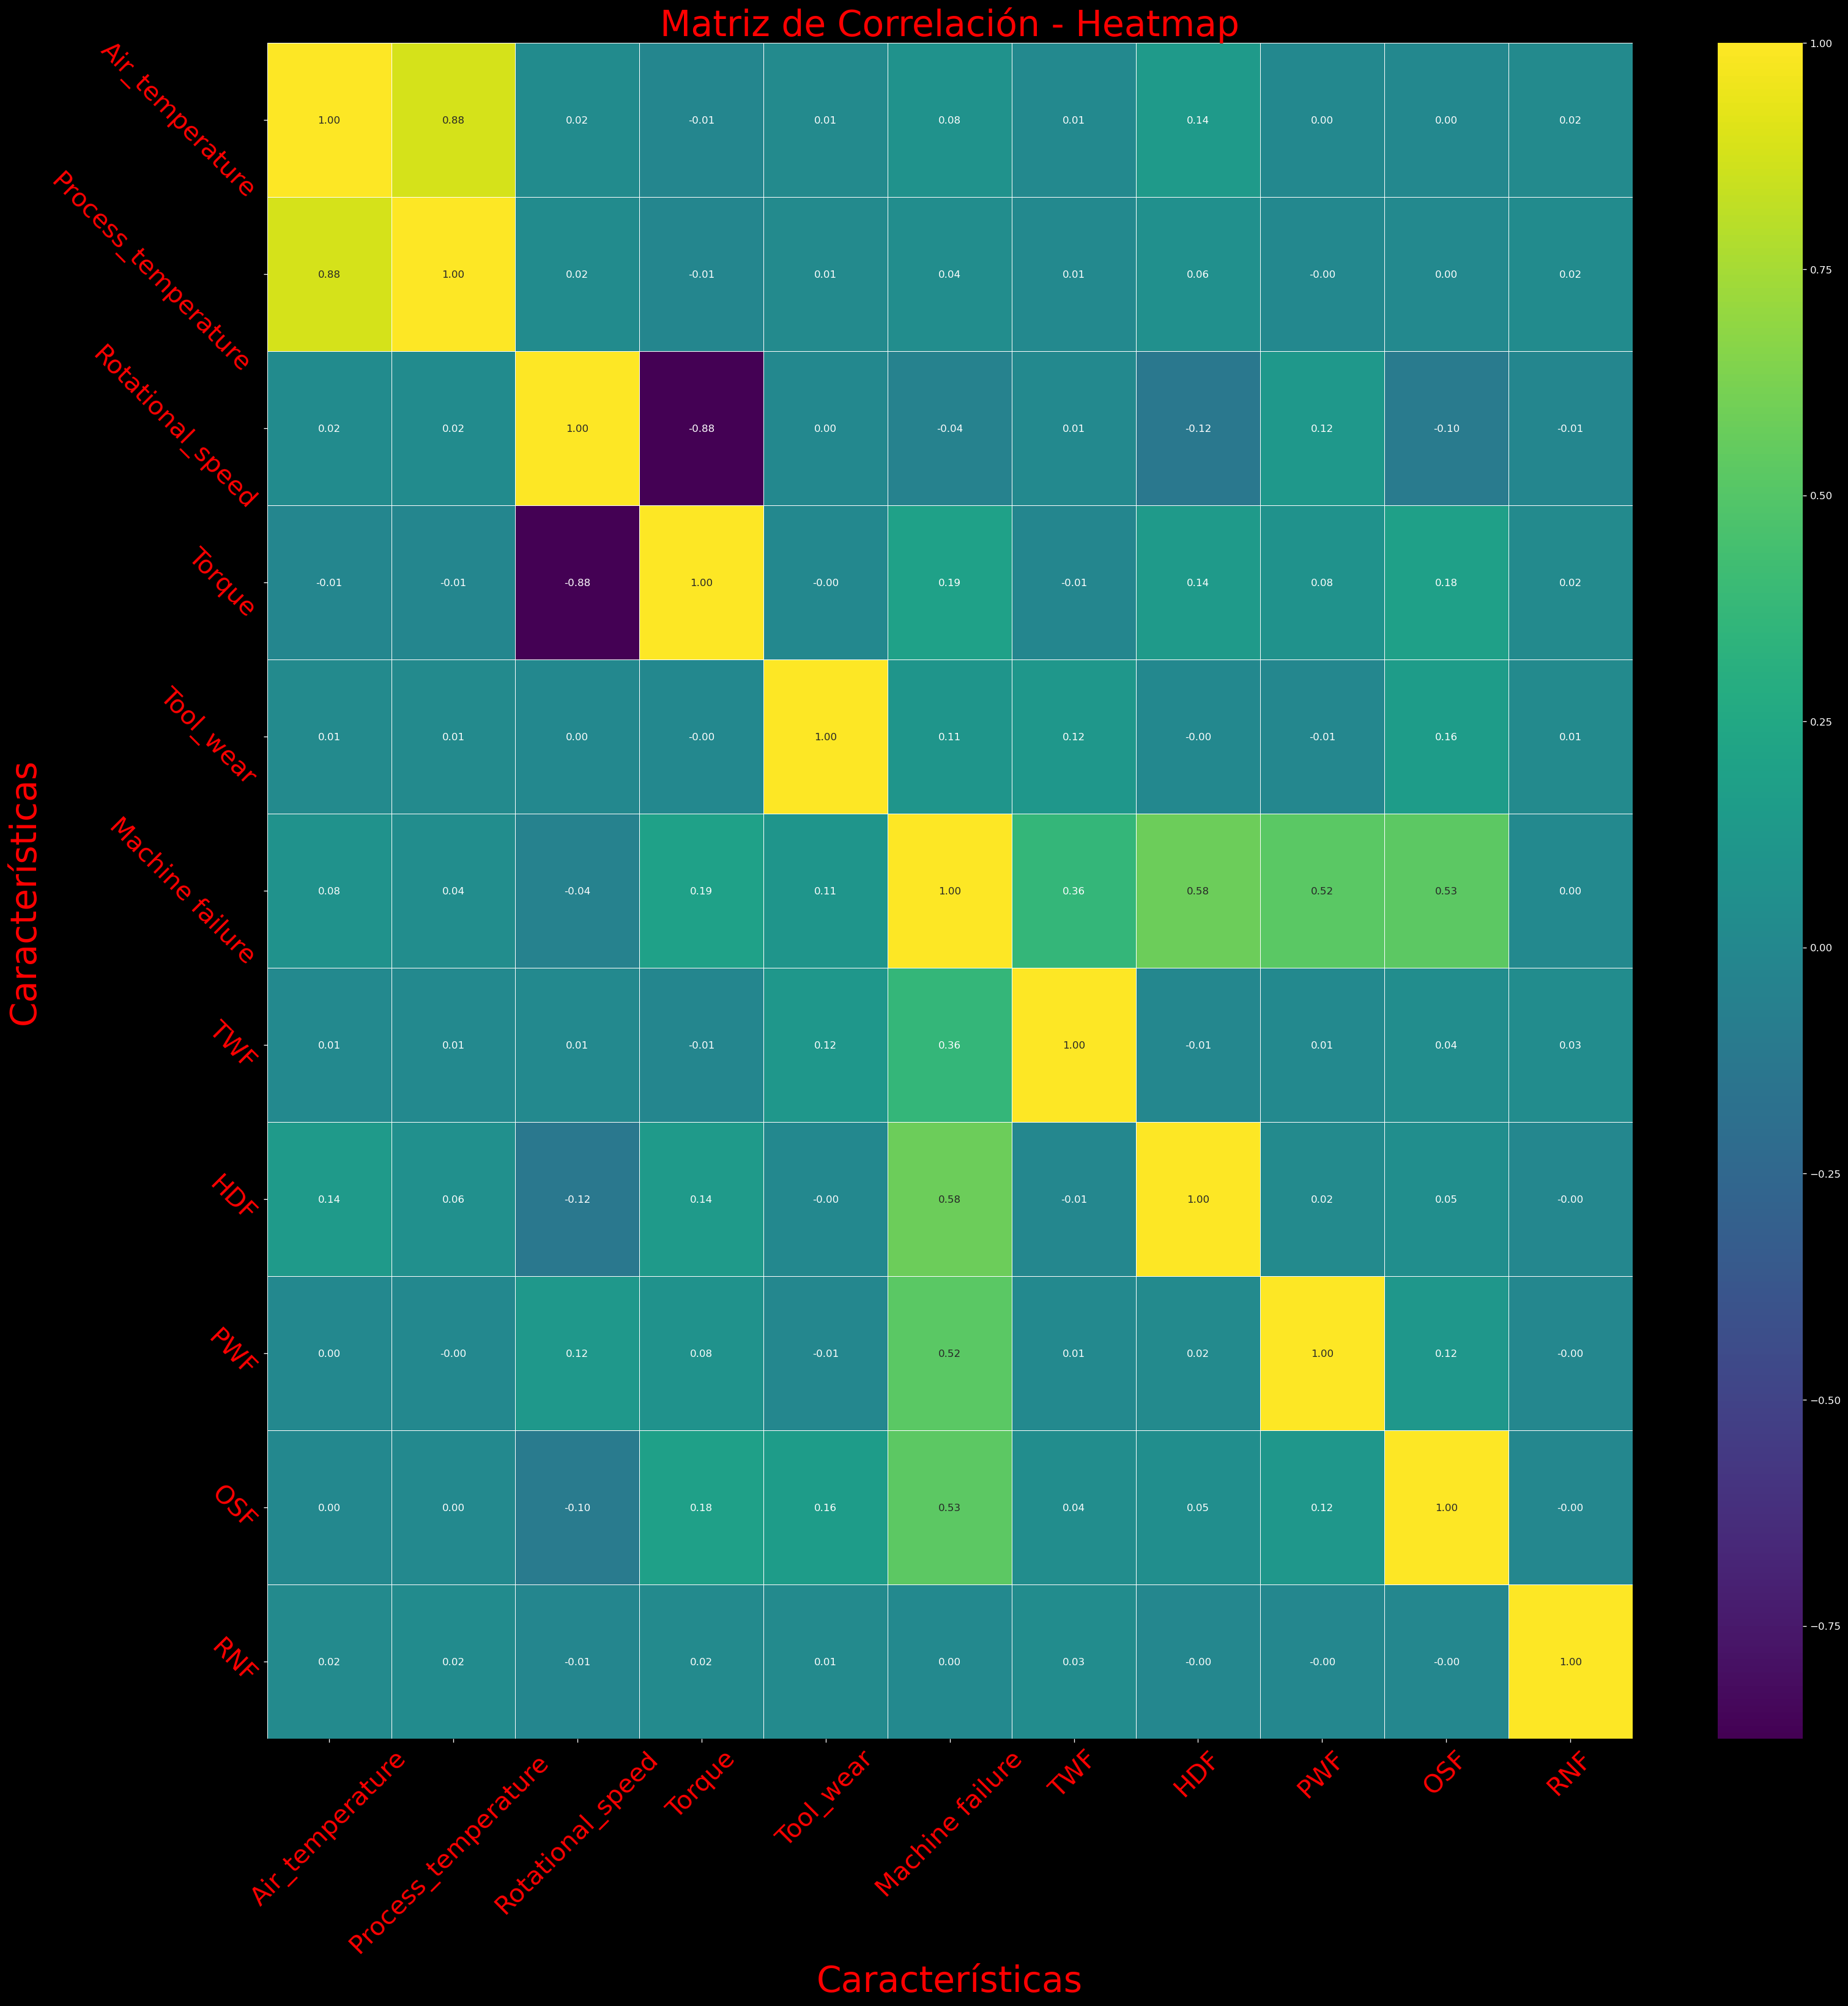

In [32]:
# Graficar el mapa de calor:
# Graficar la matriz de correlación (Heatmap):

f1 = {"family": "DejaVu Sans", "size": 35, "color": "r"}

plt.figure(figsize=(30,30), dpi=120)

sns.heatmap(
    df.select_dtypes("number").corr(),
    annot=True,
    fmt="0.2f",
    cmap='viridis',
    linewidths=0.5
)

plt.xticks(rotation=45, color="r", fontsize=25)
plt.yticks(rotation=-45, color="r", fontsize=25)

plt.xlabel("Características", fontdict=f1)
plt.ylabel("Características", fontdict=f1)

plt.title("Matriz de Correlación - Heatmap", fontdict=f1)

## Defination Outliers :

In [33]:
# found many feature contain the outliers  :
features=df.select_dtypes(include="number").columns

for col in features:
    Q1_col,Q3_col=df[col].quantile([0.25,0.75])
    iqr=Q3_col-Q1_col
    low_limit=Q1_col-1.5*iqr
    upper_limit=Q3_col+1.5*iqr
    outlier=[]
    for x in df[col]:
         if ((x> upper_limit) or (x<low_limit)):
             outlier.append(x)
    if len(outlier)==0:
        print(f" * -- >> there No outlier in {col} feature")
    else:
        print(f"Ther outlier in this feature {col}")

    print(f"Q1 of {col} --->>> {Q1_col} \n Q3 of {col} ---->>> {Q3_col} \n iqr--->>{iqr}\n low_limit--->>>{low_limit} \n  upper_limit--->>> {upper_limit} \n outlier---->>> {outlier} \n Number of outliers --->>> {len(outlier)} ")
    print("-"*90)
    

 * -- >> there No outlier in Air_temperature feature
Q1 of Air_temperature --->>> 26.150000000000034 
 Q3 of Air_temperature ---->>> 29.350000000000023 
 iqr--->>3.1999999999999886
 low_limit--->>>21.35000000000005 
  upper_limit--->>> 34.150000000000006 
 outlier---->>> [] 
 Number of outliers --->>> 0 
------------------------------------------------------------------------------------------
 * -- >> there No outlier in Process_temperature  feature
Q1 of Process_temperature  --->>> 36.650000000000034 
 Q3 of Process_temperature  ---->>> 38.950000000000045 
 iqr--->>2.3000000000000114
 low_limit--->>>33.20000000000002 
  upper_limit--->>> 42.40000000000006 
 outlier---->>> [] 
 Number of outliers --->>> 0 
------------------------------------------------------------------------------------------
Ther outlier in this feature Rotational_speed
Q1 of Rotational_speed --->>> 1423.0 
 Q3 of Rotational_speed ---->>> 1612.0 
 iqr--->>189.0
 low_limit--->>>1139.5 
  upper_limit--->>> 1895.5 
 

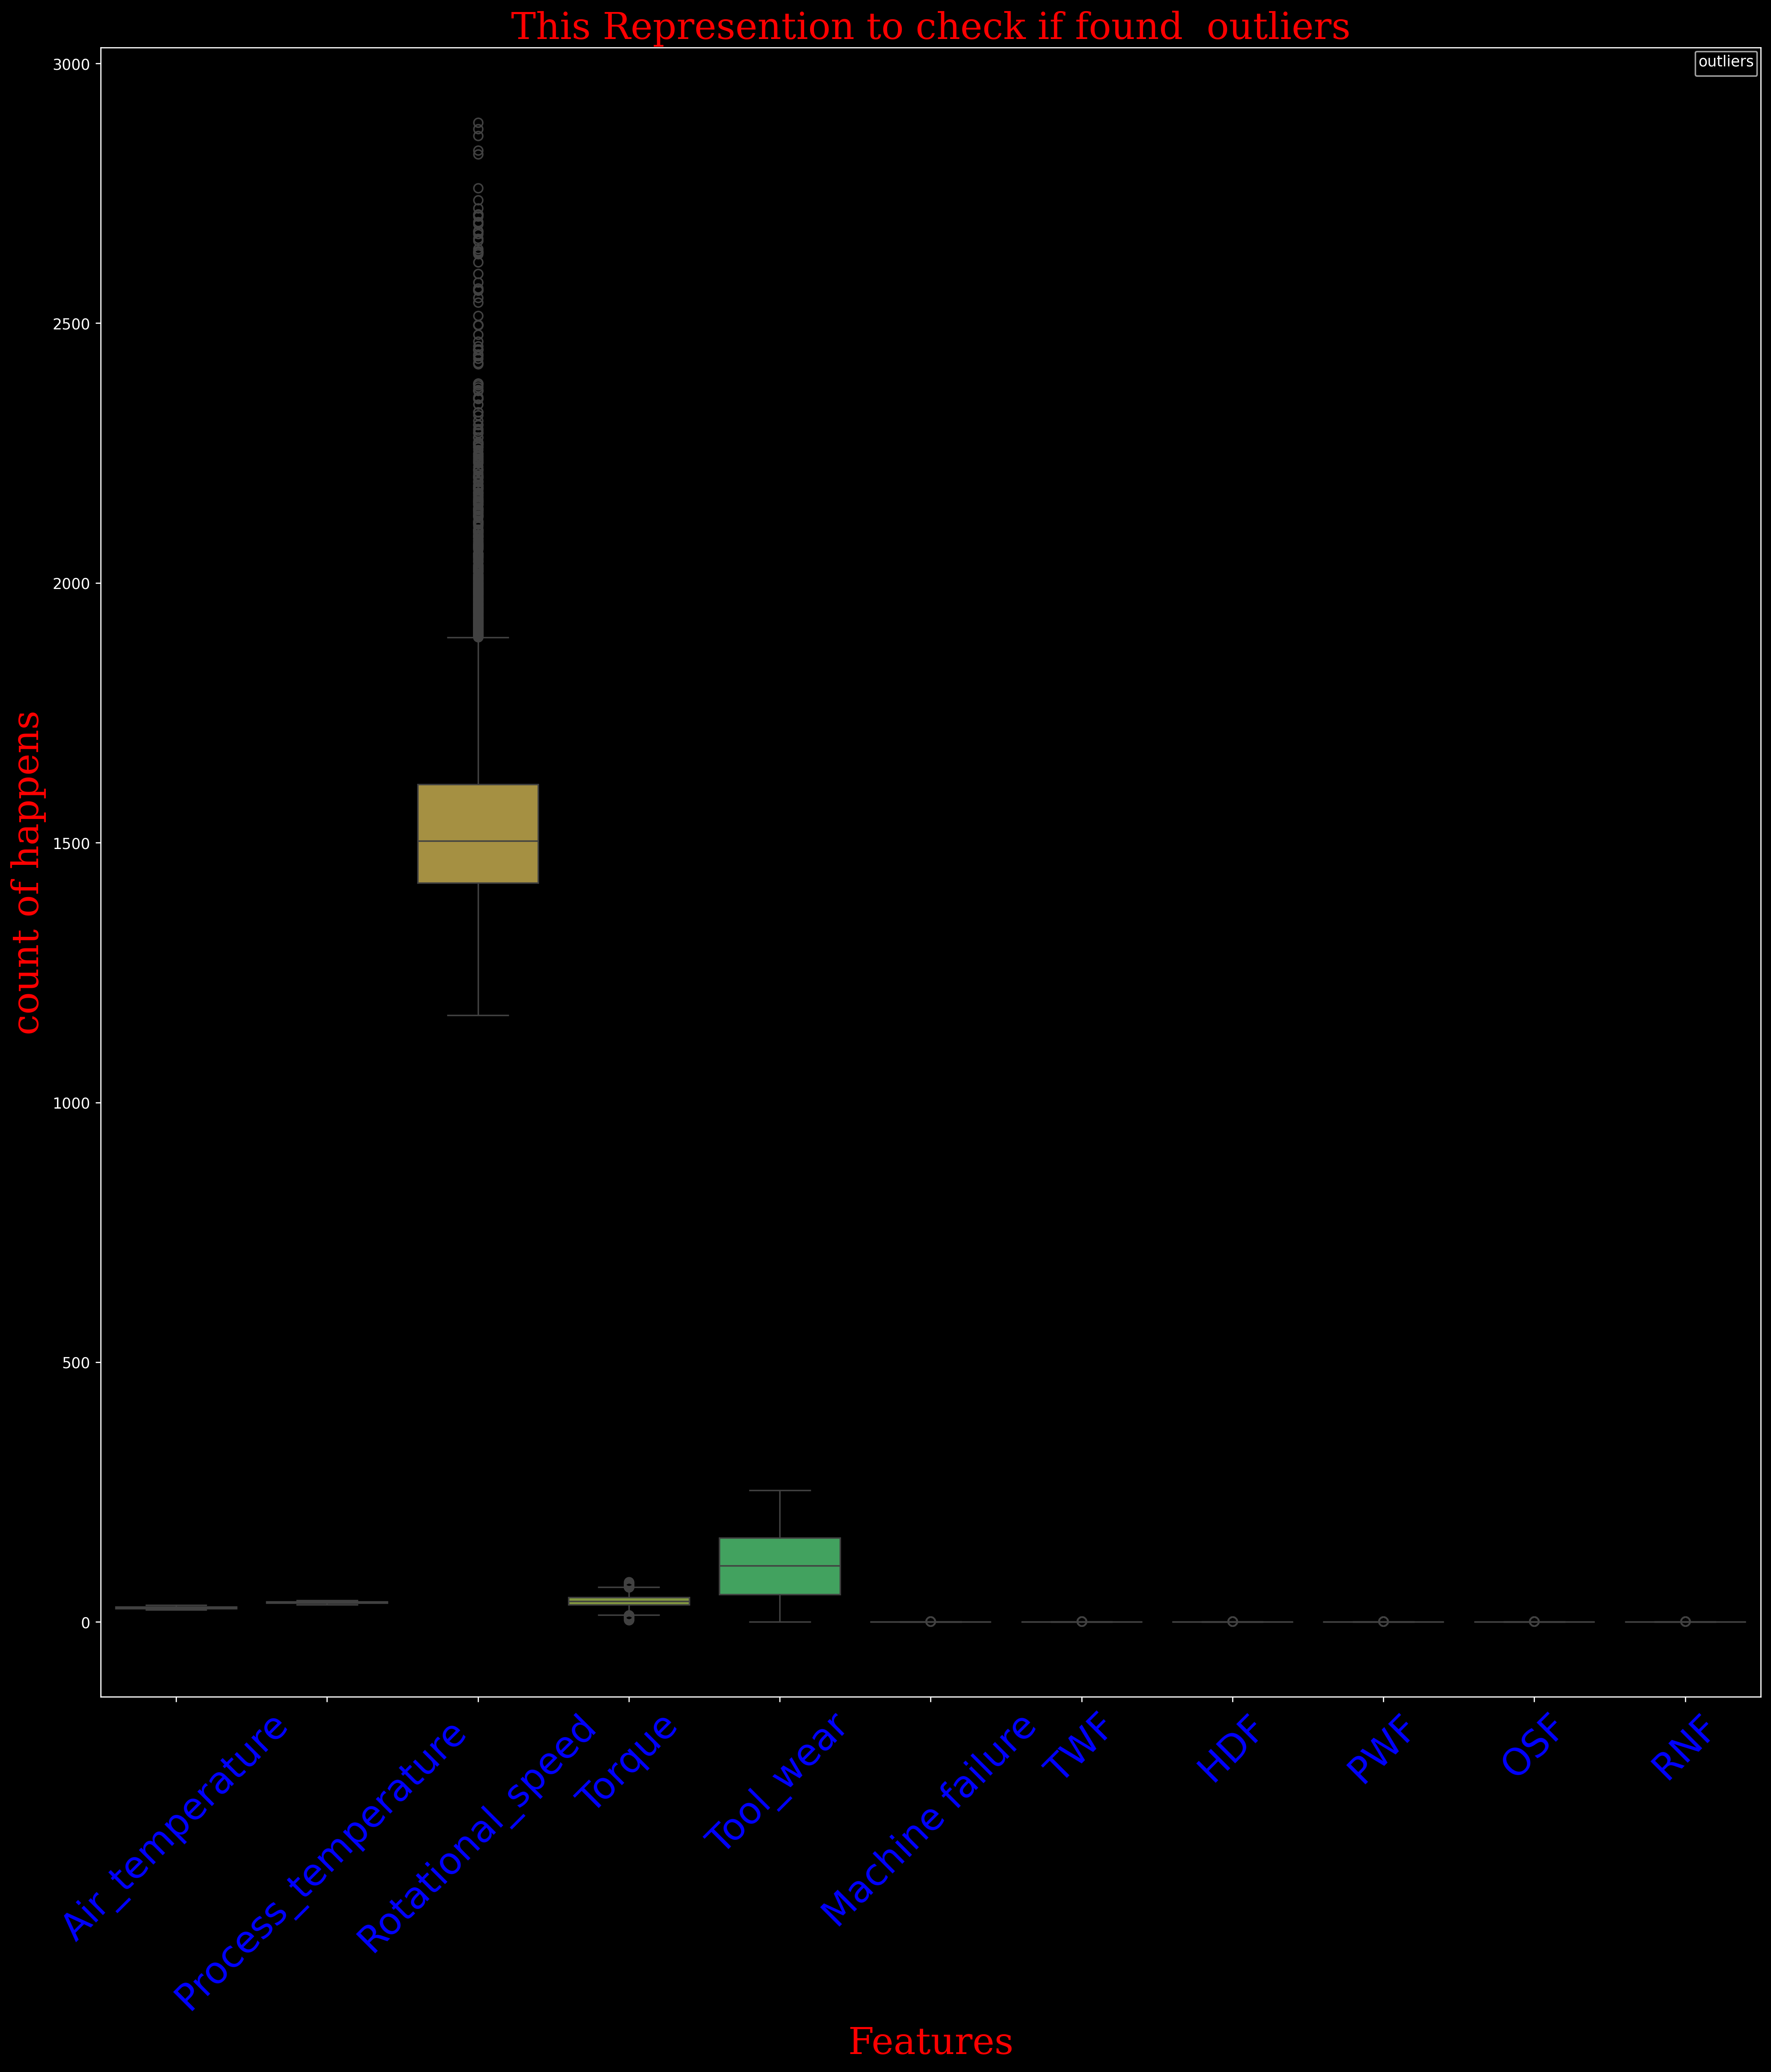

In [34]:
# from this Represention we discover that we found outliers :

f1={"family":"serif","size":25,"color":"r"}
plt.figure(figsize=(20,20),dpi=250)
plt.title("This Represention to check if found  outliers",fontdict=f1)
plt.xlabel("Features",fontdict=f1)
plt.ylabel("count of happens",fontdict=f1)
plt.xticks(rotation=45,color="b",fontsize=25)
sns.boxplot(df[features])
plt.legend(title="outliers",prop={'size': 5})

In [39]:
# Renombrar columna
df.rename(columns={'Machine failure': 'Target'}, inplace=True)

# Verificar columnas
print(df.columns)

Index(['Type', 'Air_temperature', 'Process_temperature ', 'Rotational_speed',
       'Torque', 'Tool_wear', 'Target', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')


In [40]:
# split the data int train & test :

x_class,y_class=make_classification()
x_class=df.drop("Target",axis=1)
y_class=df["Target"]

In [41]:
def remove_outliers_iqr(df):
    outlier_counts = {}
    outlier_means = {}
    
    
    for column in df.select_dtypes(include=[np.number]).columns:  
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Identify outliers
        
        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
        
        outlier_counts[column] = outliers.shape[0]
        
        # Calculate mean of outliers if any exist
        
        if not outliers.empty:
            outlier_means[column] = outliers[column].mean()
        else:
            outlier_means[column] = 0.0
        
        # Remove outliers from the DataFrame
        
        df_cleaned_without_target = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    
    return df_cleaned_without_target, outlier_counts, outlier_means


df_cleaned_without_target, outlier_counts, outlier_means = remove_outliers_iqr(x_class)


# Display the results
print("Number of outliers detected in each column:")
print(outlier_counts)
print("-" * 70)
print("\nMean of outliers in each column:")
print(outlier_means)
print("-" * 70)
print("\nDataFrame after removing outliers:")
print(df_cleaned_without_target)

Number of outliers detected in each column:
{'Air_temperature': 0, 'Process_temperature ': 0, 'Rotational_speed': 418, 'Torque': 69, 'Tool_wear': 0, 'TWF': 46, 'HDF': 115, 'PWF': 95, 'OSF': 98, 'RNF': 19}
----------------------------------------------------------------------

Mean of outliers in each column:
{'Air_temperature': 0.0, 'Process_temperature ': 0.0, 'Rotational_speed': np.float64(2102.0454545454545), 'Torque': np.float64(45.620289855072464), 'Tool_wear': 0.0, 'TWF': np.float64(1.0), 'HDF': np.float64(1.0), 'PWF': np.float64(1.0), 'OSF': np.float64(1.0), 'RNF': np.float64(1.0)}
----------------------------------------------------------------------

DataFrame after removing outliers:
     Type  Air_temperature  Process_temperature   Rotational_speed  Torque  \
0       M            25.95                 36.45              1551    42.8   
1       L            26.05                 36.55              1408    46.3   
2       L            25.95                 36.35              1

## check the outliers after cleaning the data :

## Checking outliers after cleaning the Data without Target : 




<div style="border: 5px solid yellow; padding: 10px; background-color: #F5F5F5; color: black; border-radius: 30px 45px 30px 45px;">

<p> &bull; After Cleaning Data Without Target : </p> 

<p> &bull; we found that : number outliers in columans that was inside it outliers is Reduced </p> 

<p> &bull; outliers : For that we will fill this outliers to make the Data Cleaning  .</p> 

</div>

In [42]:
# found many feature contain the outliers  :

f=df_cleaned_without_target.select_dtypes(include="number").columns

for col in f:
    Q1_col,Q3_col=df_cleaned_without_target[col].quantile([0.25,0.75])
    iqr=Q3_col-Q1_col
    low_limit=Q1_col-1.5*iqr
    upper_limit=Q3_col+1.5*iqr
    outlier=[]
    for x in df_cleaned_without_target[col]:
         if ((x> upper_limit) or (x<low_limit)):
             outlier.append(x)
    if len(outlier)==0:
        print(f" * -- >> there No outlier in {col} feature")
    else:
        print(f"Ther outlier in this feature {col}")

    print(f"Q1 of {col} --->>> {Q1_col} \n Q3 of {col} ---->>> {Q3_col} \n iqr--->>{iqr}\n low_limit--->>>{low_limit} \n  upper_limit--->>> {upper_limit} \n outlier---->>> {outlier} \n Number of outliers --->>> {len(outlier)} ")
    print("-"*70)
    

 * -- >> there No outlier in Air_temperature feature
Q1 of Air_temperature --->>> 26.150000000000034 
 Q3 of Air_temperature ---->>> 29.350000000000023 
 iqr--->>3.1999999999999886
 low_limit--->>>21.35000000000005 
  upper_limit--->>> 34.150000000000006 
 outlier---->>> [] 
 Number of outliers --->>> 0 
----------------------------------------------------------------------
 * -- >> there No outlier in Process_temperature  feature
Q1 of Process_temperature  --->>> 36.650000000000034 
 Q3 of Process_temperature  ---->>> 38.950000000000045 
 iqr--->>2.3000000000000114
 low_limit--->>>33.20000000000002 
  upper_limit--->>> 42.40000000000006 
 outlier---->>> [] 
 Number of outliers --->>> 0 
----------------------------------------------------------------------
Ther outlier in this feature Rotational_speed
Q1 of Rotational_speed --->>> 1423.0 
 Q3 of Rotational_speed ---->>> 1612.0 
 iqr--->>189.0
 low_limit--->>>1139.5 
  upper_limit--->>> 1895.5 
 outlier---->>> [2035, 2861, 1924, 1991, 

In [43]:
def replace_outliers(df):
    quantiles = df.quantile([0.25, 0.75])
    
    # Calculate lower and upper bounds
    lower_bound = quantiles[0.25] - (quantiles[0.75] - quantiles[0.25]) * 1.5
    upper_bound = quantiles[0.75] + (quantiles[0.75] - quantiles[0.25]) * 1.5
    
    # replace outliers with minimum or maximum values
    df = df.apply(lambda x: np.where((x < lower_bound), np.min(x), 
                                      np.where(x > upper_bound, np.max(x), x)))
    
    return df

# Fillna outliers in this features:

df_cleaned_without_target["Rotational_speed"]=replace_outliers(df_cleaned_without_target["Rotational_speed"])
df_cleaned_without_target["Torque"]=replace_outliers(df_cleaned_without_target["Torque"])
print("Data after cleand Data & fillna outliers :",np.shape(df_cleaned_without_target))
print("Data after only Remove outliers :",np.shape(df))

Data after cleand Data & fillna outliers : (9981, 11)
Data after only Remove outliers : (10000, 12)


## Visualization :

In [44]:
df.head(5)

,Type,Air_temperature,Process_temperature,Rotational_speed,Torque,Tool_wear,Target,TWF,HDF,PWF,OSF,RNF
0,M,25.95,36.45,1551,42.8,0,0,0,0,0,0,0
1,L,26.05,36.55,1408,46.3,3,0,0,0,0,0,0
2,L,25.95,36.35,1498,49.4,5,0,0,0,0,0,0
3,L,26.05,36.45,1433,39.5,7,0,0,0,0,0,0
4,L,26.05,36.55,1408,40.0,9,0,0,0,0,0,0


In [45]:
# Pie plot

color_palette = ['#00FF00', '#DFFF00', '#228B22', '#808000', '#2E8B57', '#008080']
Type = df.groupby("Type")["Air_temperature"].mean().sort_values(ascending=False)
type_index = Type.reset_index()
print("Rates of Air_temperature at every tupes :\n",Type)

fig = make_subplots(rows=1, cols=2, specs=[[{'type': 'pie'}, {'type': 'bar'}]])

# Add pie plot
fig.add_trace(go.Pie(labels=type_index['Type'], values=type_index['Air_temperature'], marker=dict(colors=color_palette)), row=1, col=1)

# Bar plot
fig.add_trace(go.Bar(name='Air_temperature', x=df["Type"], y=df["Air_temperature"], marker_color="#7CFC00"), row=1, col=2)

# Update layout
fig.update_layout(
    title="Observation Type vs Air_temperature",
    legend_title="Types & Air_temperature",
    width=1200,
    height=600,
    showlegend=True
)

# Show the plot
fig.show()


Rates of Air_temperature at every tupes :
 Type
M    27.879263
L    27.865833
H    27.716999
Name: Air_temperature, dtype: float64


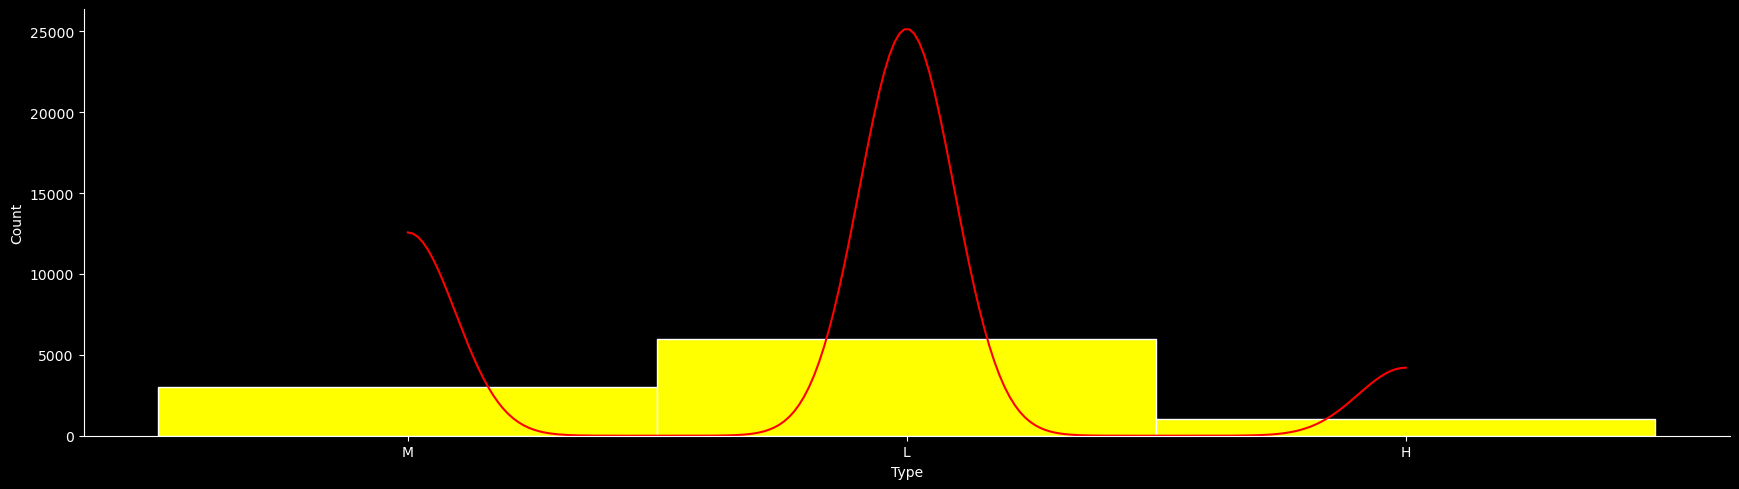

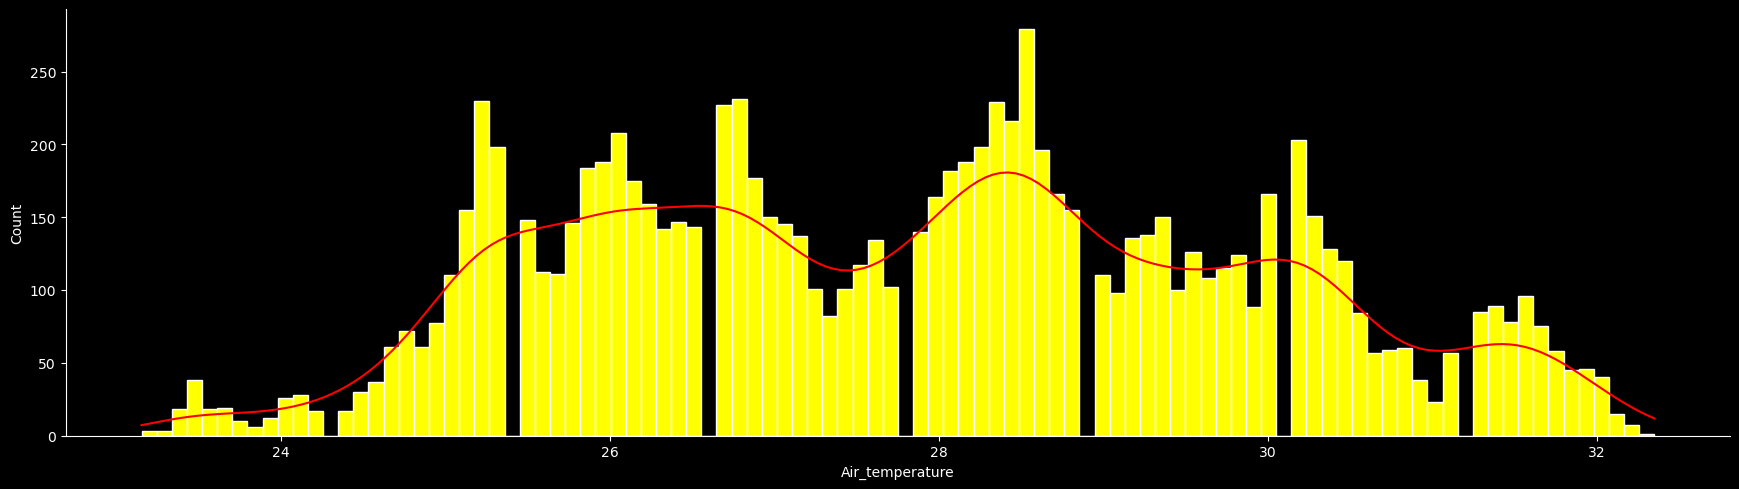

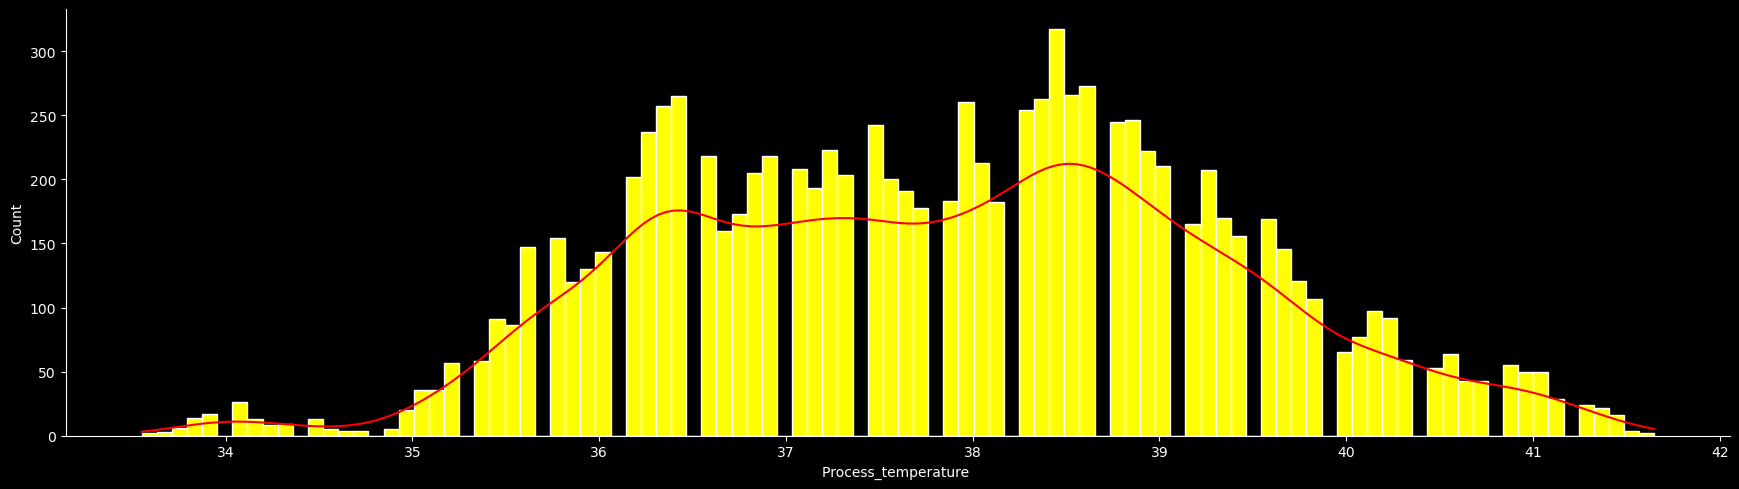

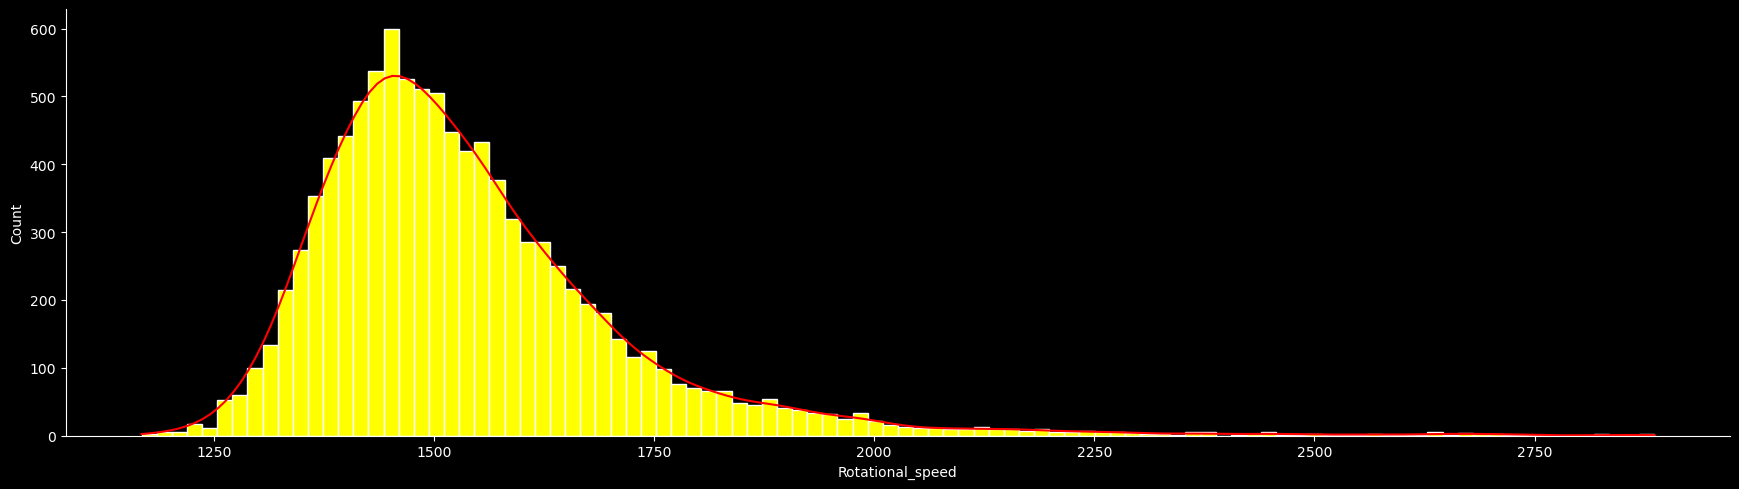

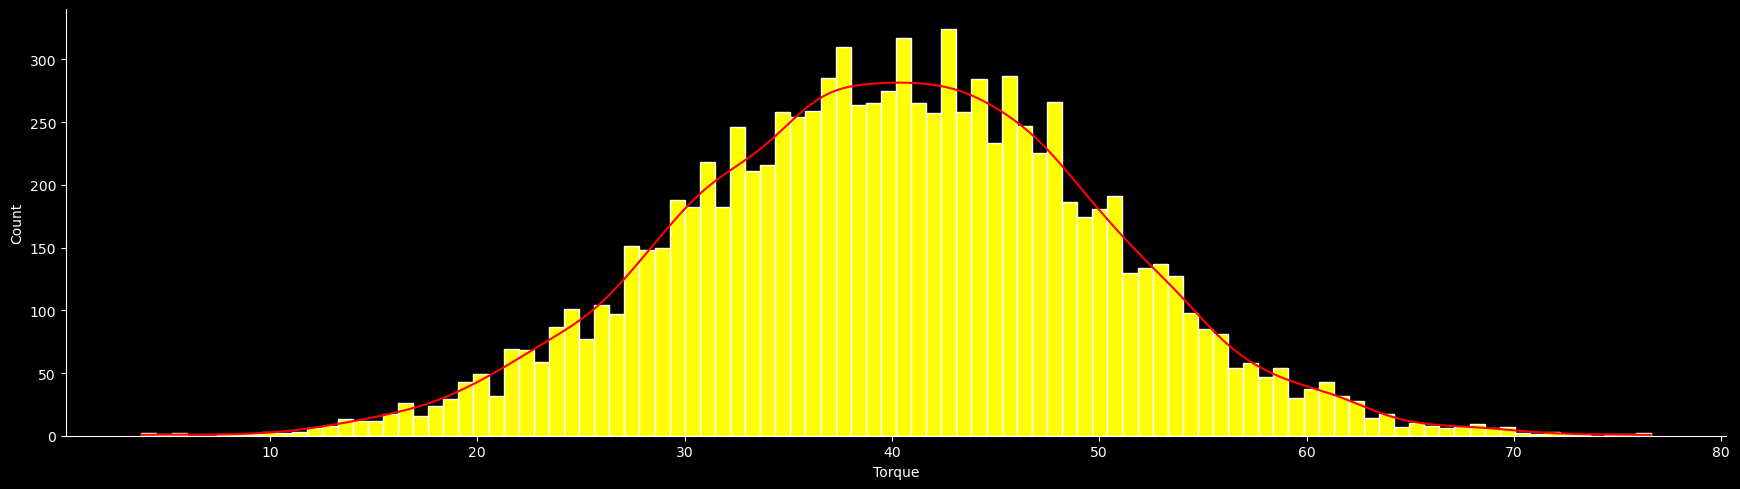

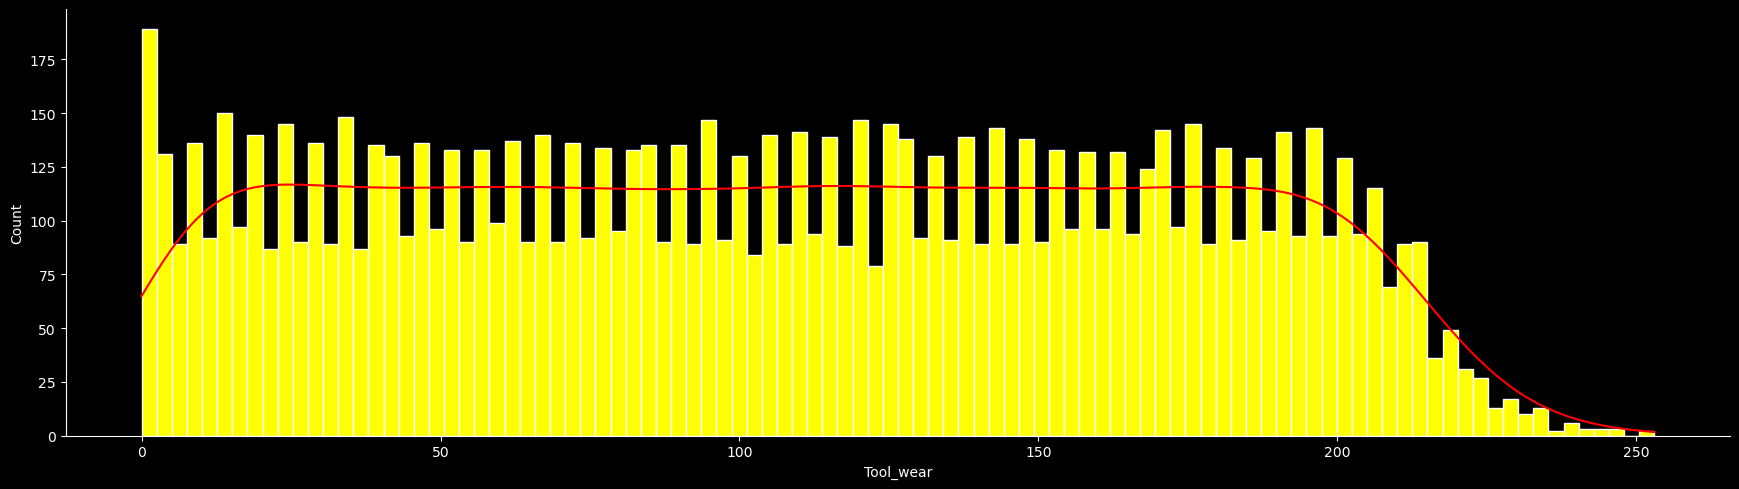

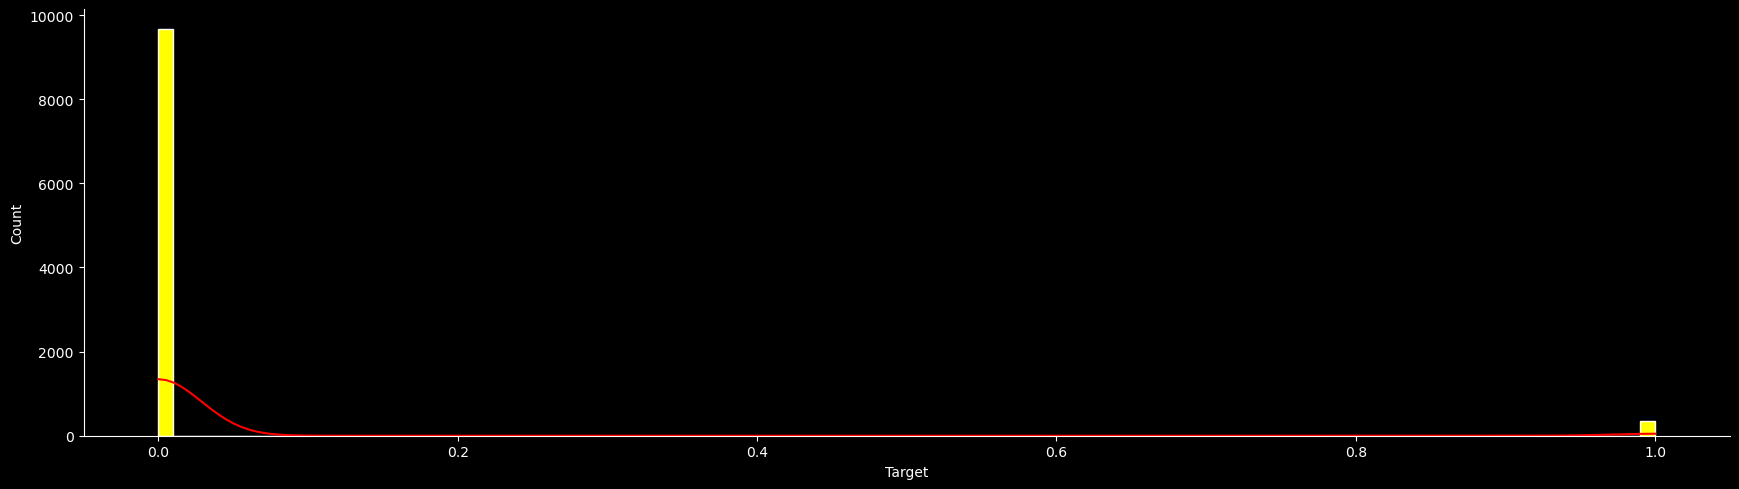

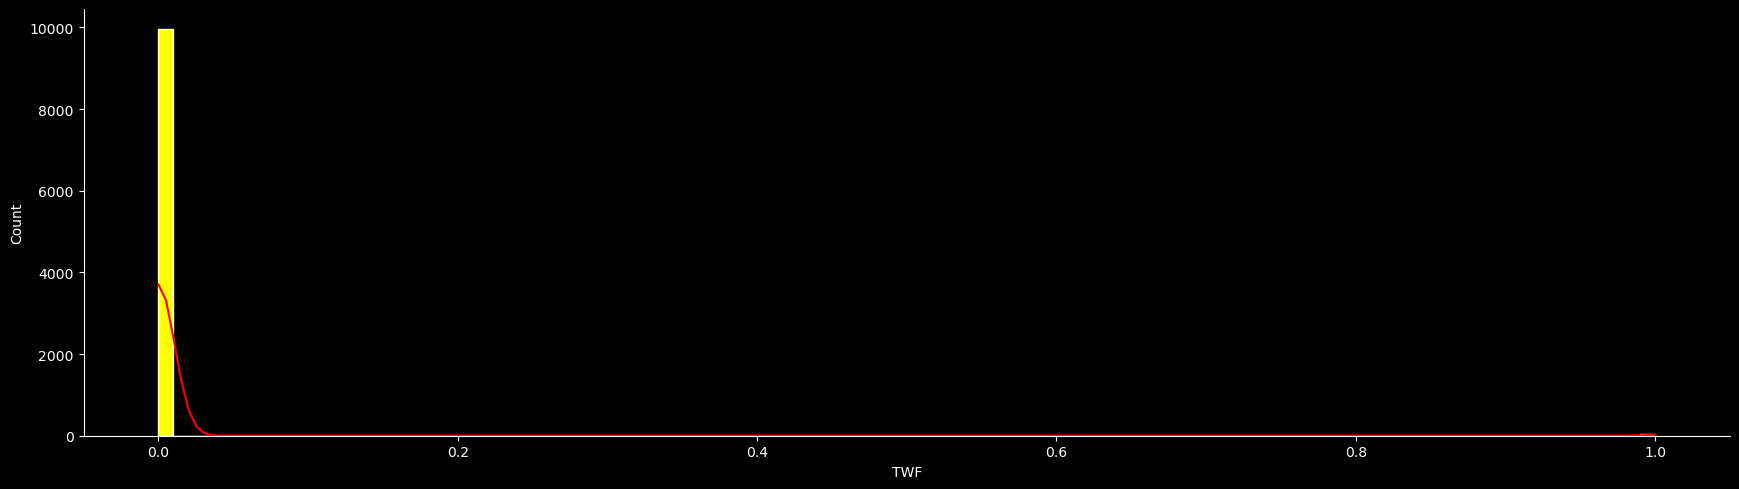

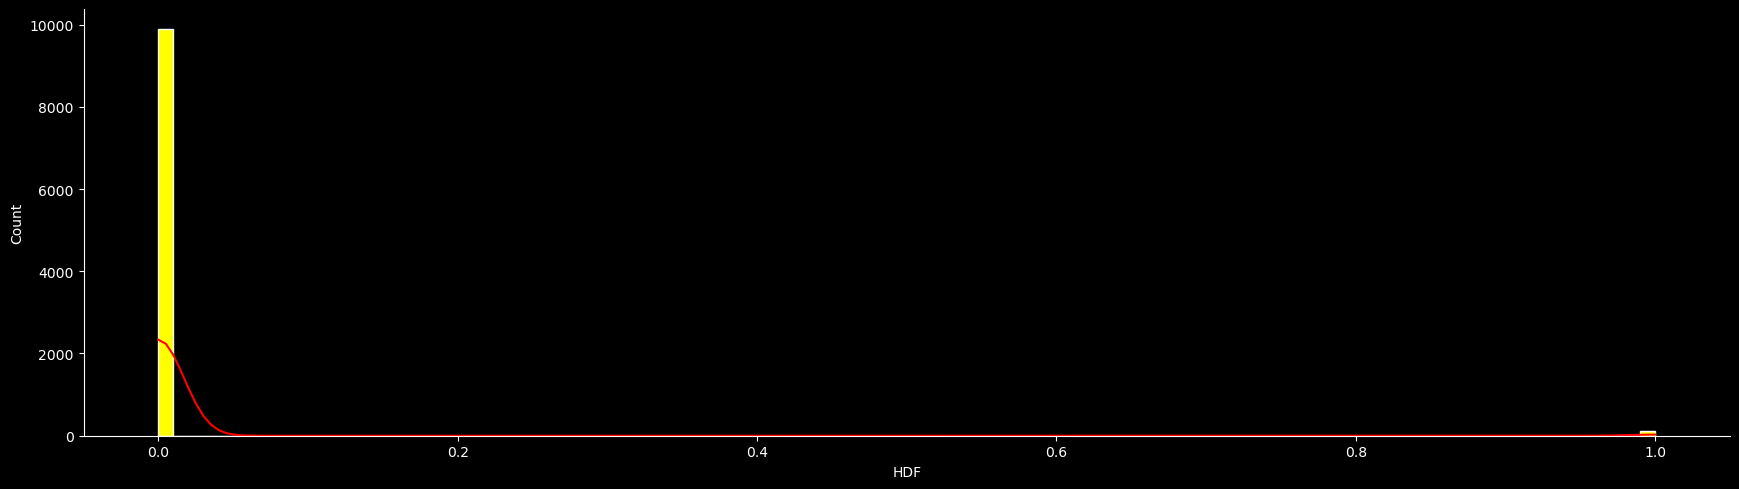

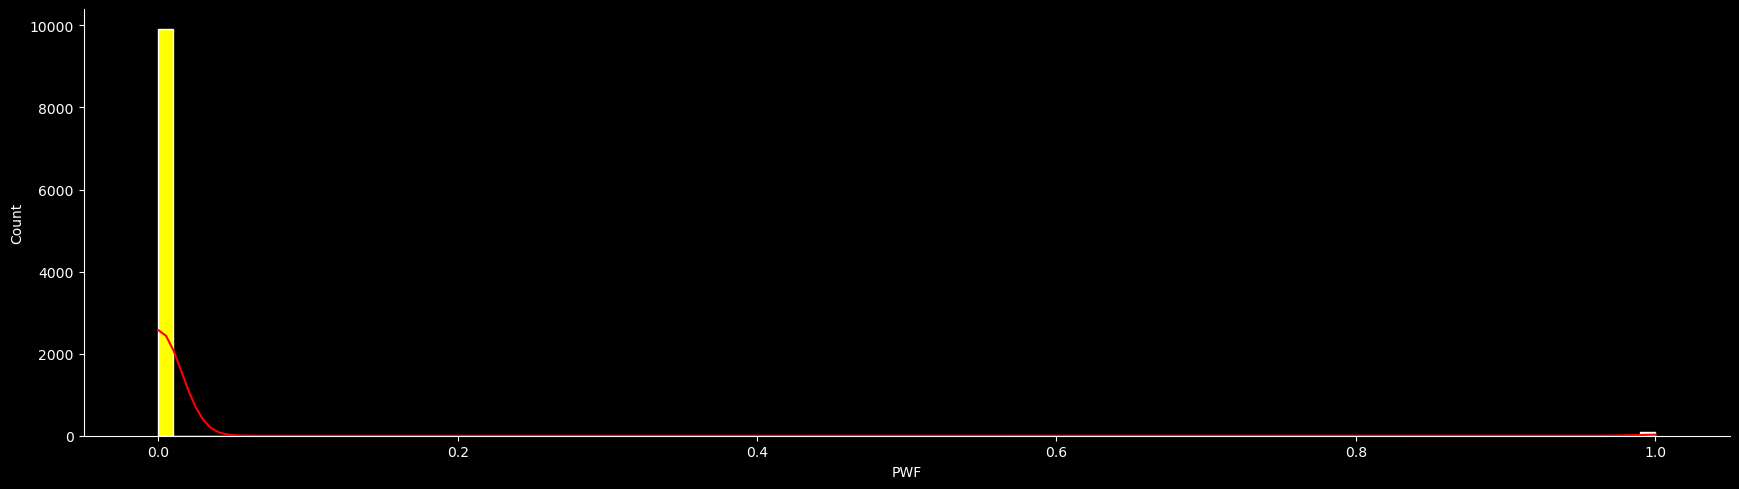

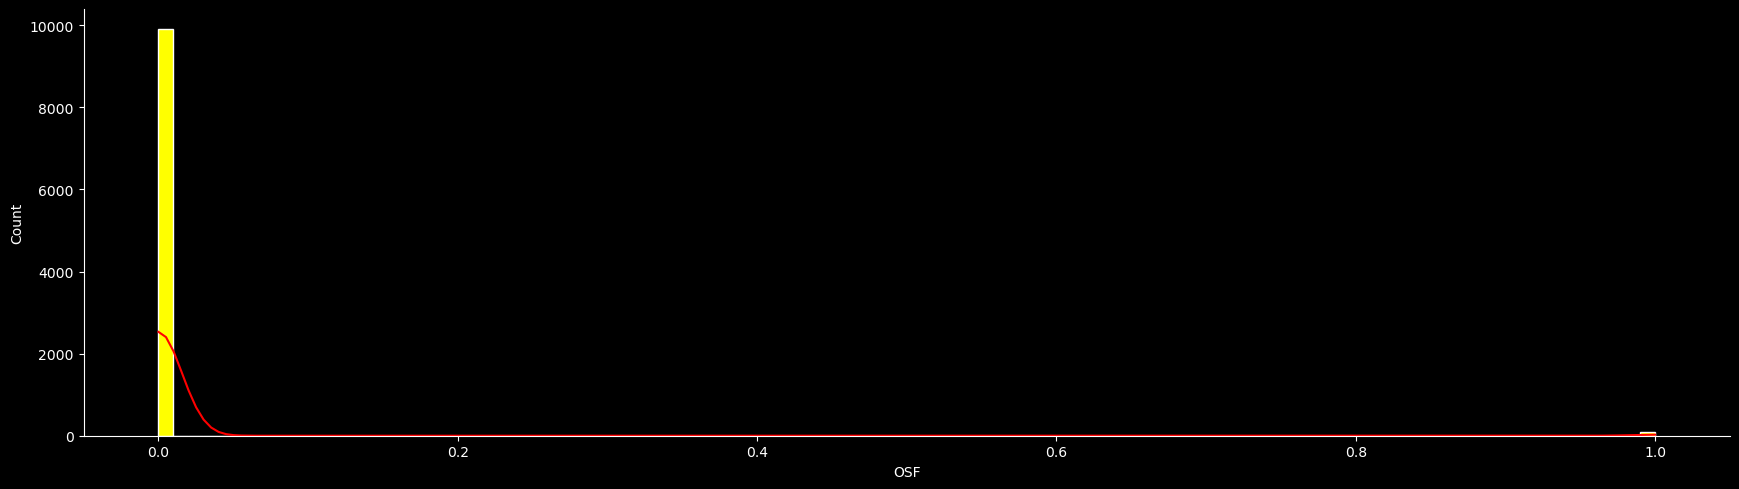

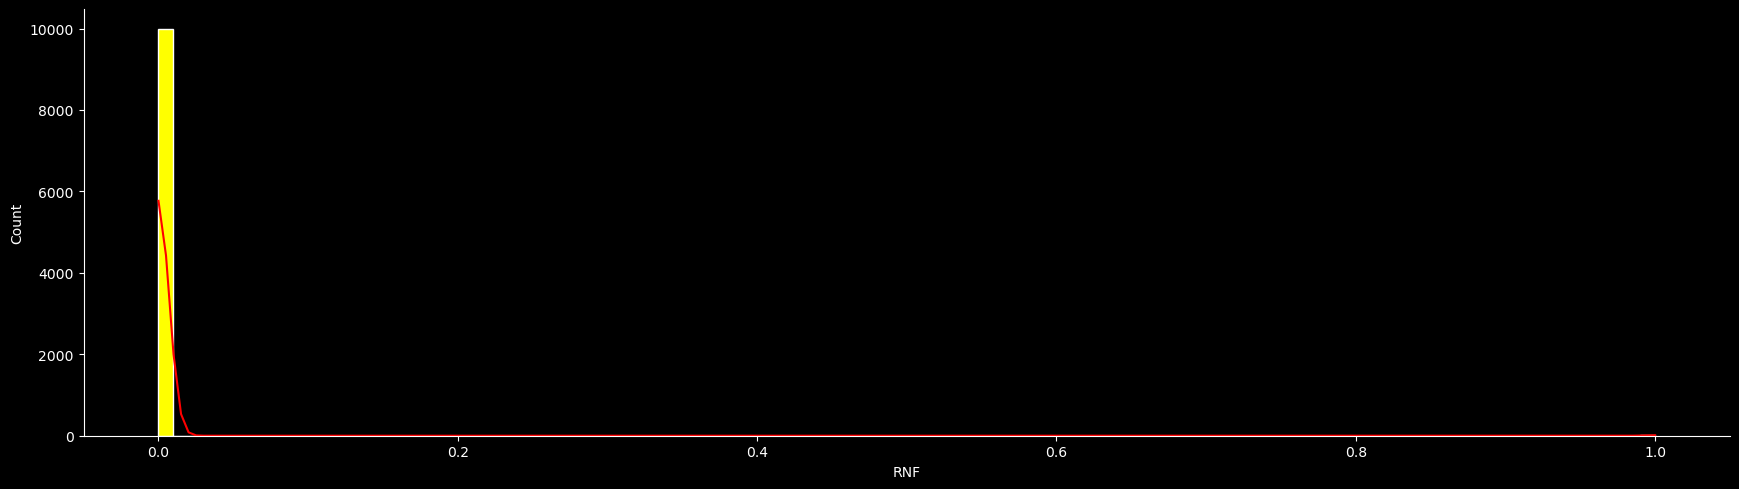

In [46]:
for col in df.columns:
    sns.displot(df, x=df[col], kde=True, bins = 100,color = "red", facecolor = "yellow",height = 5, aspect = 3.5);
    

In [47]:
df.select_dtypes("number").columns

Index(['Air_temperature', 'Process_temperature ', 'Rotational_speed', 'Torque',
       'Tool_wear', 'Target', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')

In [49]:
import plotly.express as px

print("No Relationship:")

fig = px.scatter(
    df,
    x='Air_temperature',
    y='Rotational_speed',
    color='Rotational_speed',
    color_discrete_sequence=color_palette
)

fig.update_layout(
    title="Air_temperature vs Rotational_speed",
    xaxis_title="Air_temperature",
    yaxis_title="Rotational_speed"
)

fig.show()

No Relationship:


In [ ]:
df.columns

Index(['Type', 'Air_temperature', 'Process_temperature ', 'Rotational_speed',
       'Torque', 'Tool_wear', 'Target', 'Failure_Type'],
      dtype='object')

In [56]:
# Histogram that show how can see Air_temperature with Type  :
fig = px.histogram(df, x="Air_temperature", color="Type")
fig.update_layout(
    bargap=0.2,
    title="Observation Air_temperaturev .vs Type",
    legend_title="Type",
    width=800,  
    height=600  
)
fig.show()




In [ ]:
df.columns

Index(['Type', 'Air_temperature', 'Process_temperature ', 'Rotational_speed',
       'Torque', 'Tool_wear', 'Target', 'Failure_Type'],
      dtype='object')

In [57]:
# Pie plot
color_palette = ['#00FF00', '#DFFF00', '#228B22', '#808000', '#2E8B57', '#008080']
Type = df.groupby("Type")["Torque"].mean().sort_values(ascending=False)
type_index = Type.reset_index()

print("Rates of Torque at every type:\n", Type)

fig = make_subplots(rows=1, cols=2, specs=[[{'type': 'pie'}, {'type': 'bar'}]])

# Add pie plot
fig.add_trace(go.Pie(labels=type_index['Type'], values=type_index['Torque'], marker=dict(colors=color_palette)), row=1, col=1)

# Bar plot
fig.add_trace(go.Bar(name='Torque', x=df["Type"], y=df["Torque"], marker_color="#239b56"), row=1, col=2)

# Update layout
fig.update_layout(
    title="Observation Type vs Torque",
    legend_title="Types & Torque",
    width=1200,
    height=600,
    showlegend=True
)

# Show the plot
fig.show()

Rates of Torque at every type:
 Type
M    40.017251
L    39.996600
H    39.838285
Name: Torque, dtype: float64


array([[<Axes: title={'center': 'Air_temperature'}>,
        <Axes: title={'center': 'Process_temperature '}>,
        <Axes: title={'center': 'Rotational_speed'}>],
       [<Axes: title={'center': 'Torque'}>,
        <Axes: title={'center': 'Tool_wear'}>,
        <Axes: title={'center': 'Target'}>],
       [<Axes: title={'center': 'TWF'}>, <Axes: title={'center': 'HDF'}>,
        <Axes: title={'center': 'PWF'}>],
       [<Axes: title={'center': 'OSF'}>, <Axes: title={'center': 'RNF'}>,
        <Axes: >]], dtype=object)

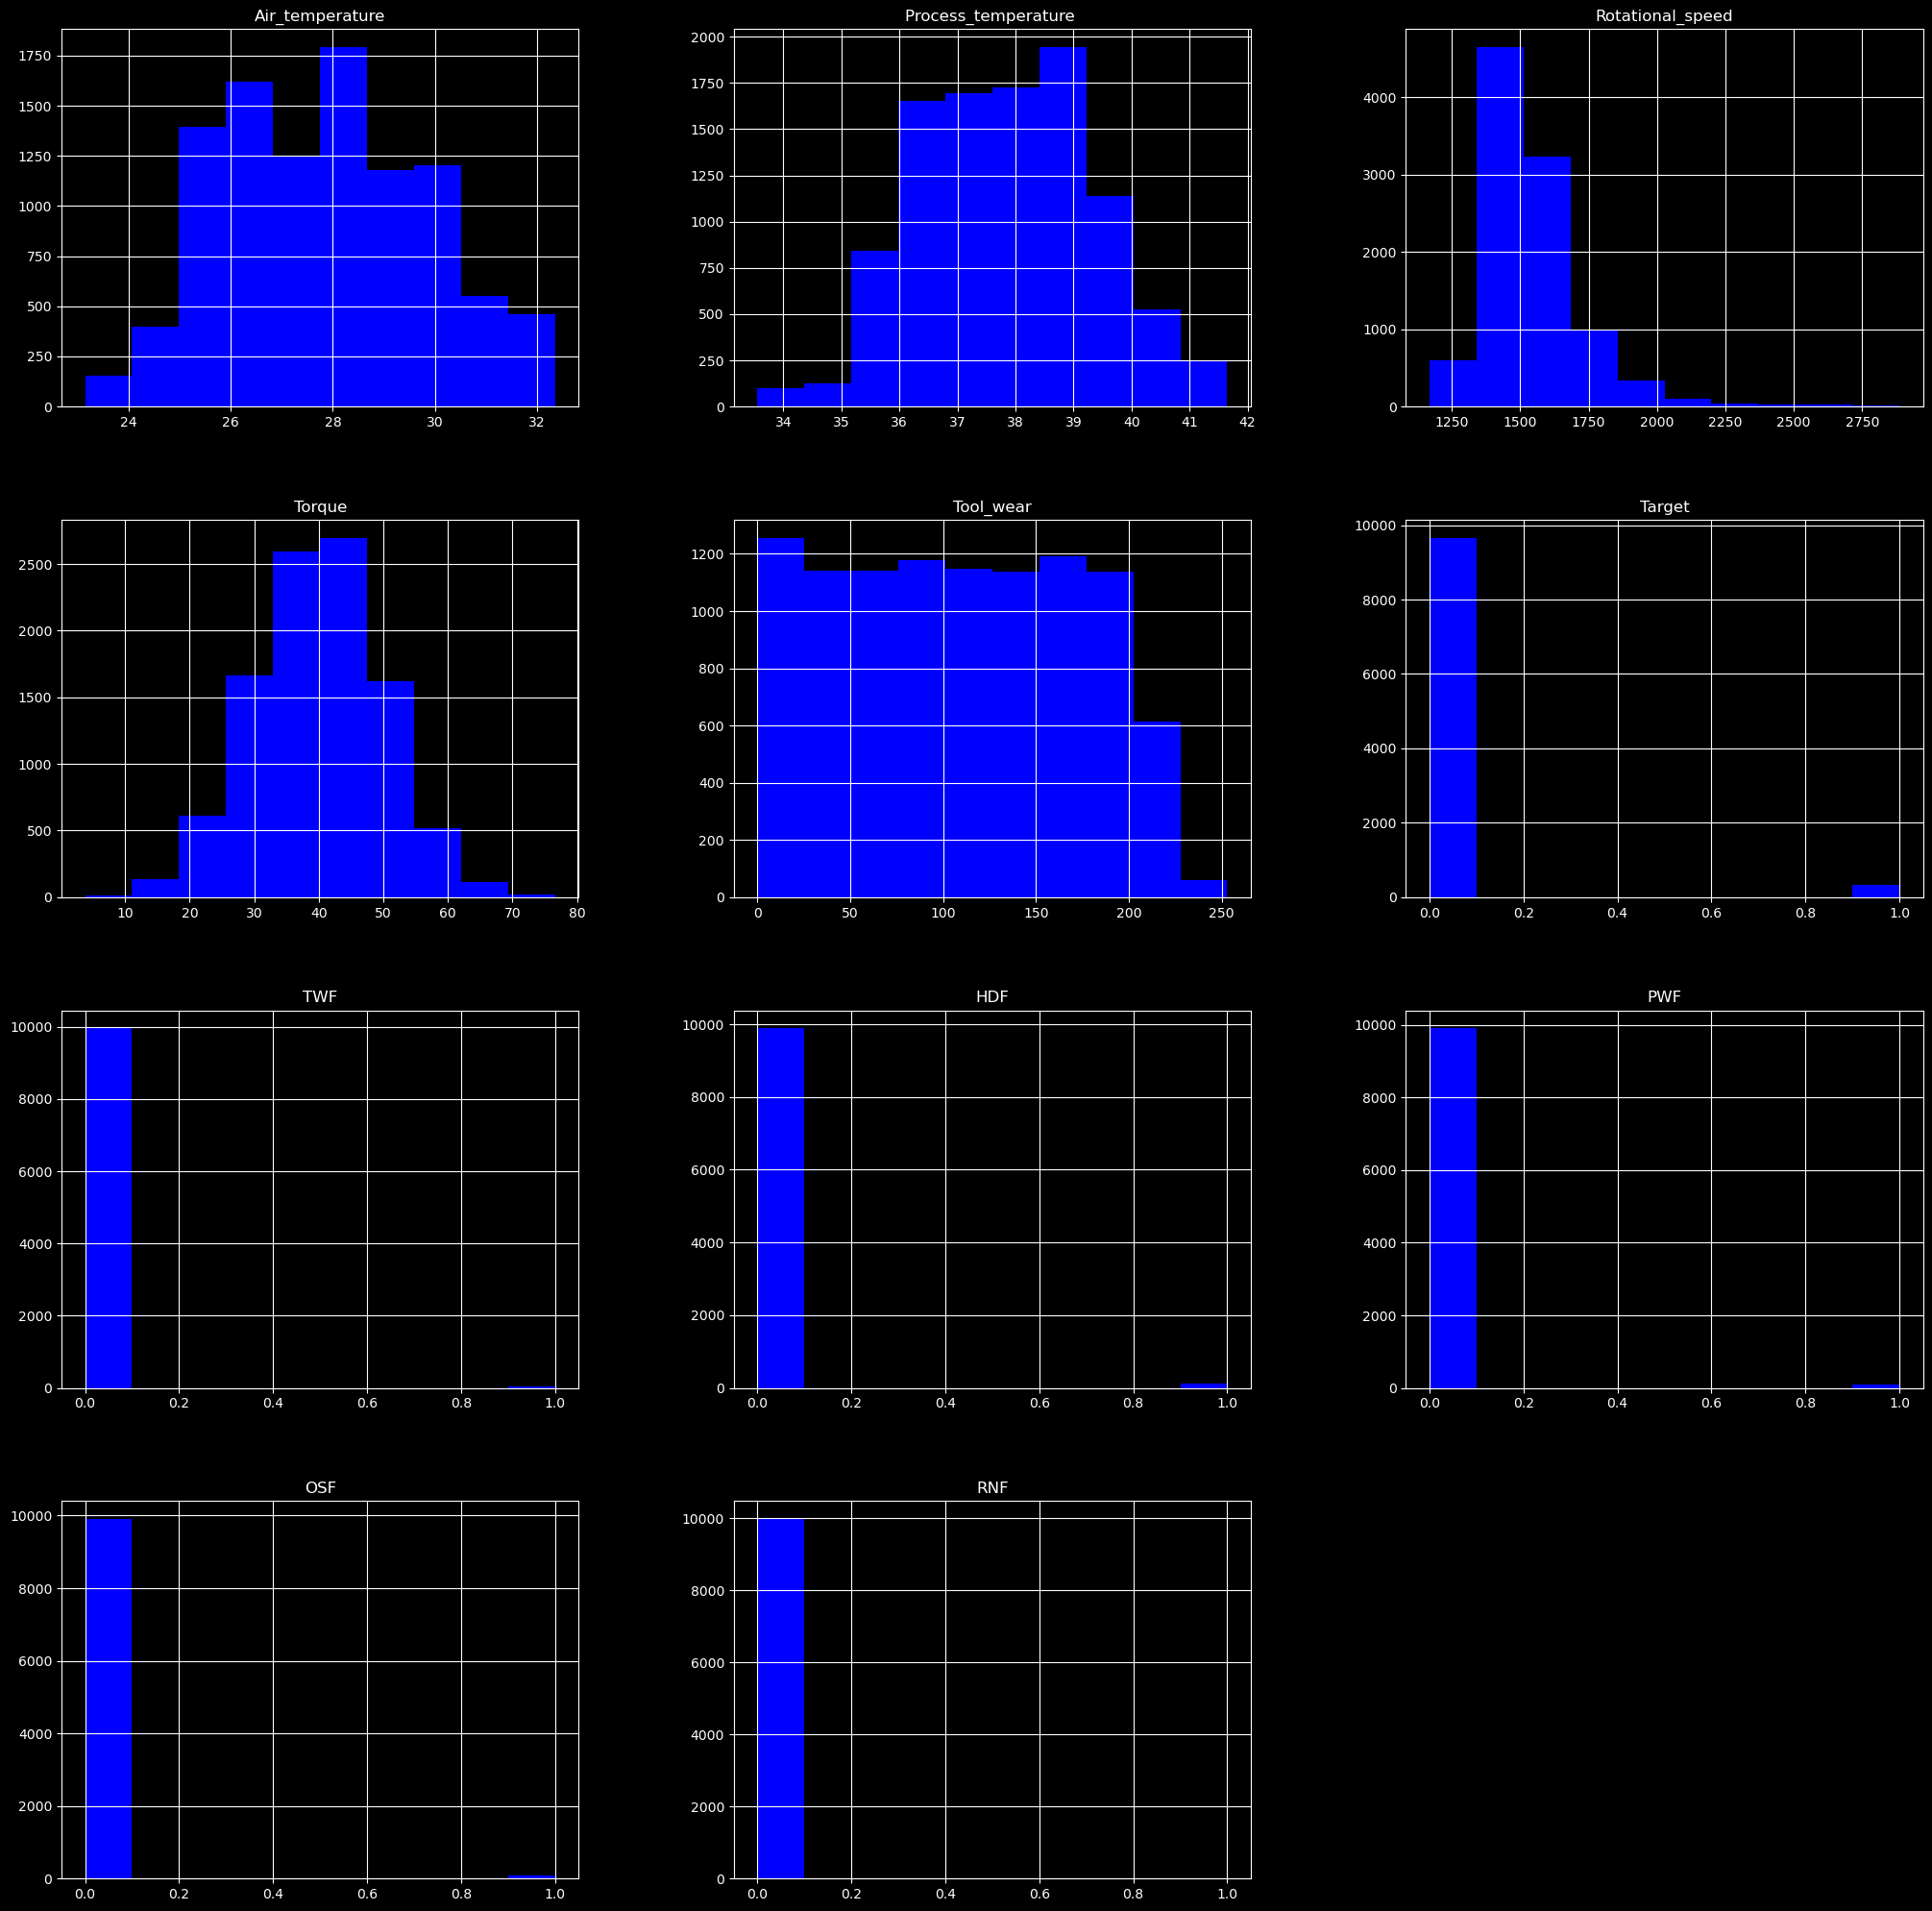

In [58]:
# plot the histgram:
df.hist(figsize=(25,25),color="b")

<Figure size 6250x6250 with 0 Axes>

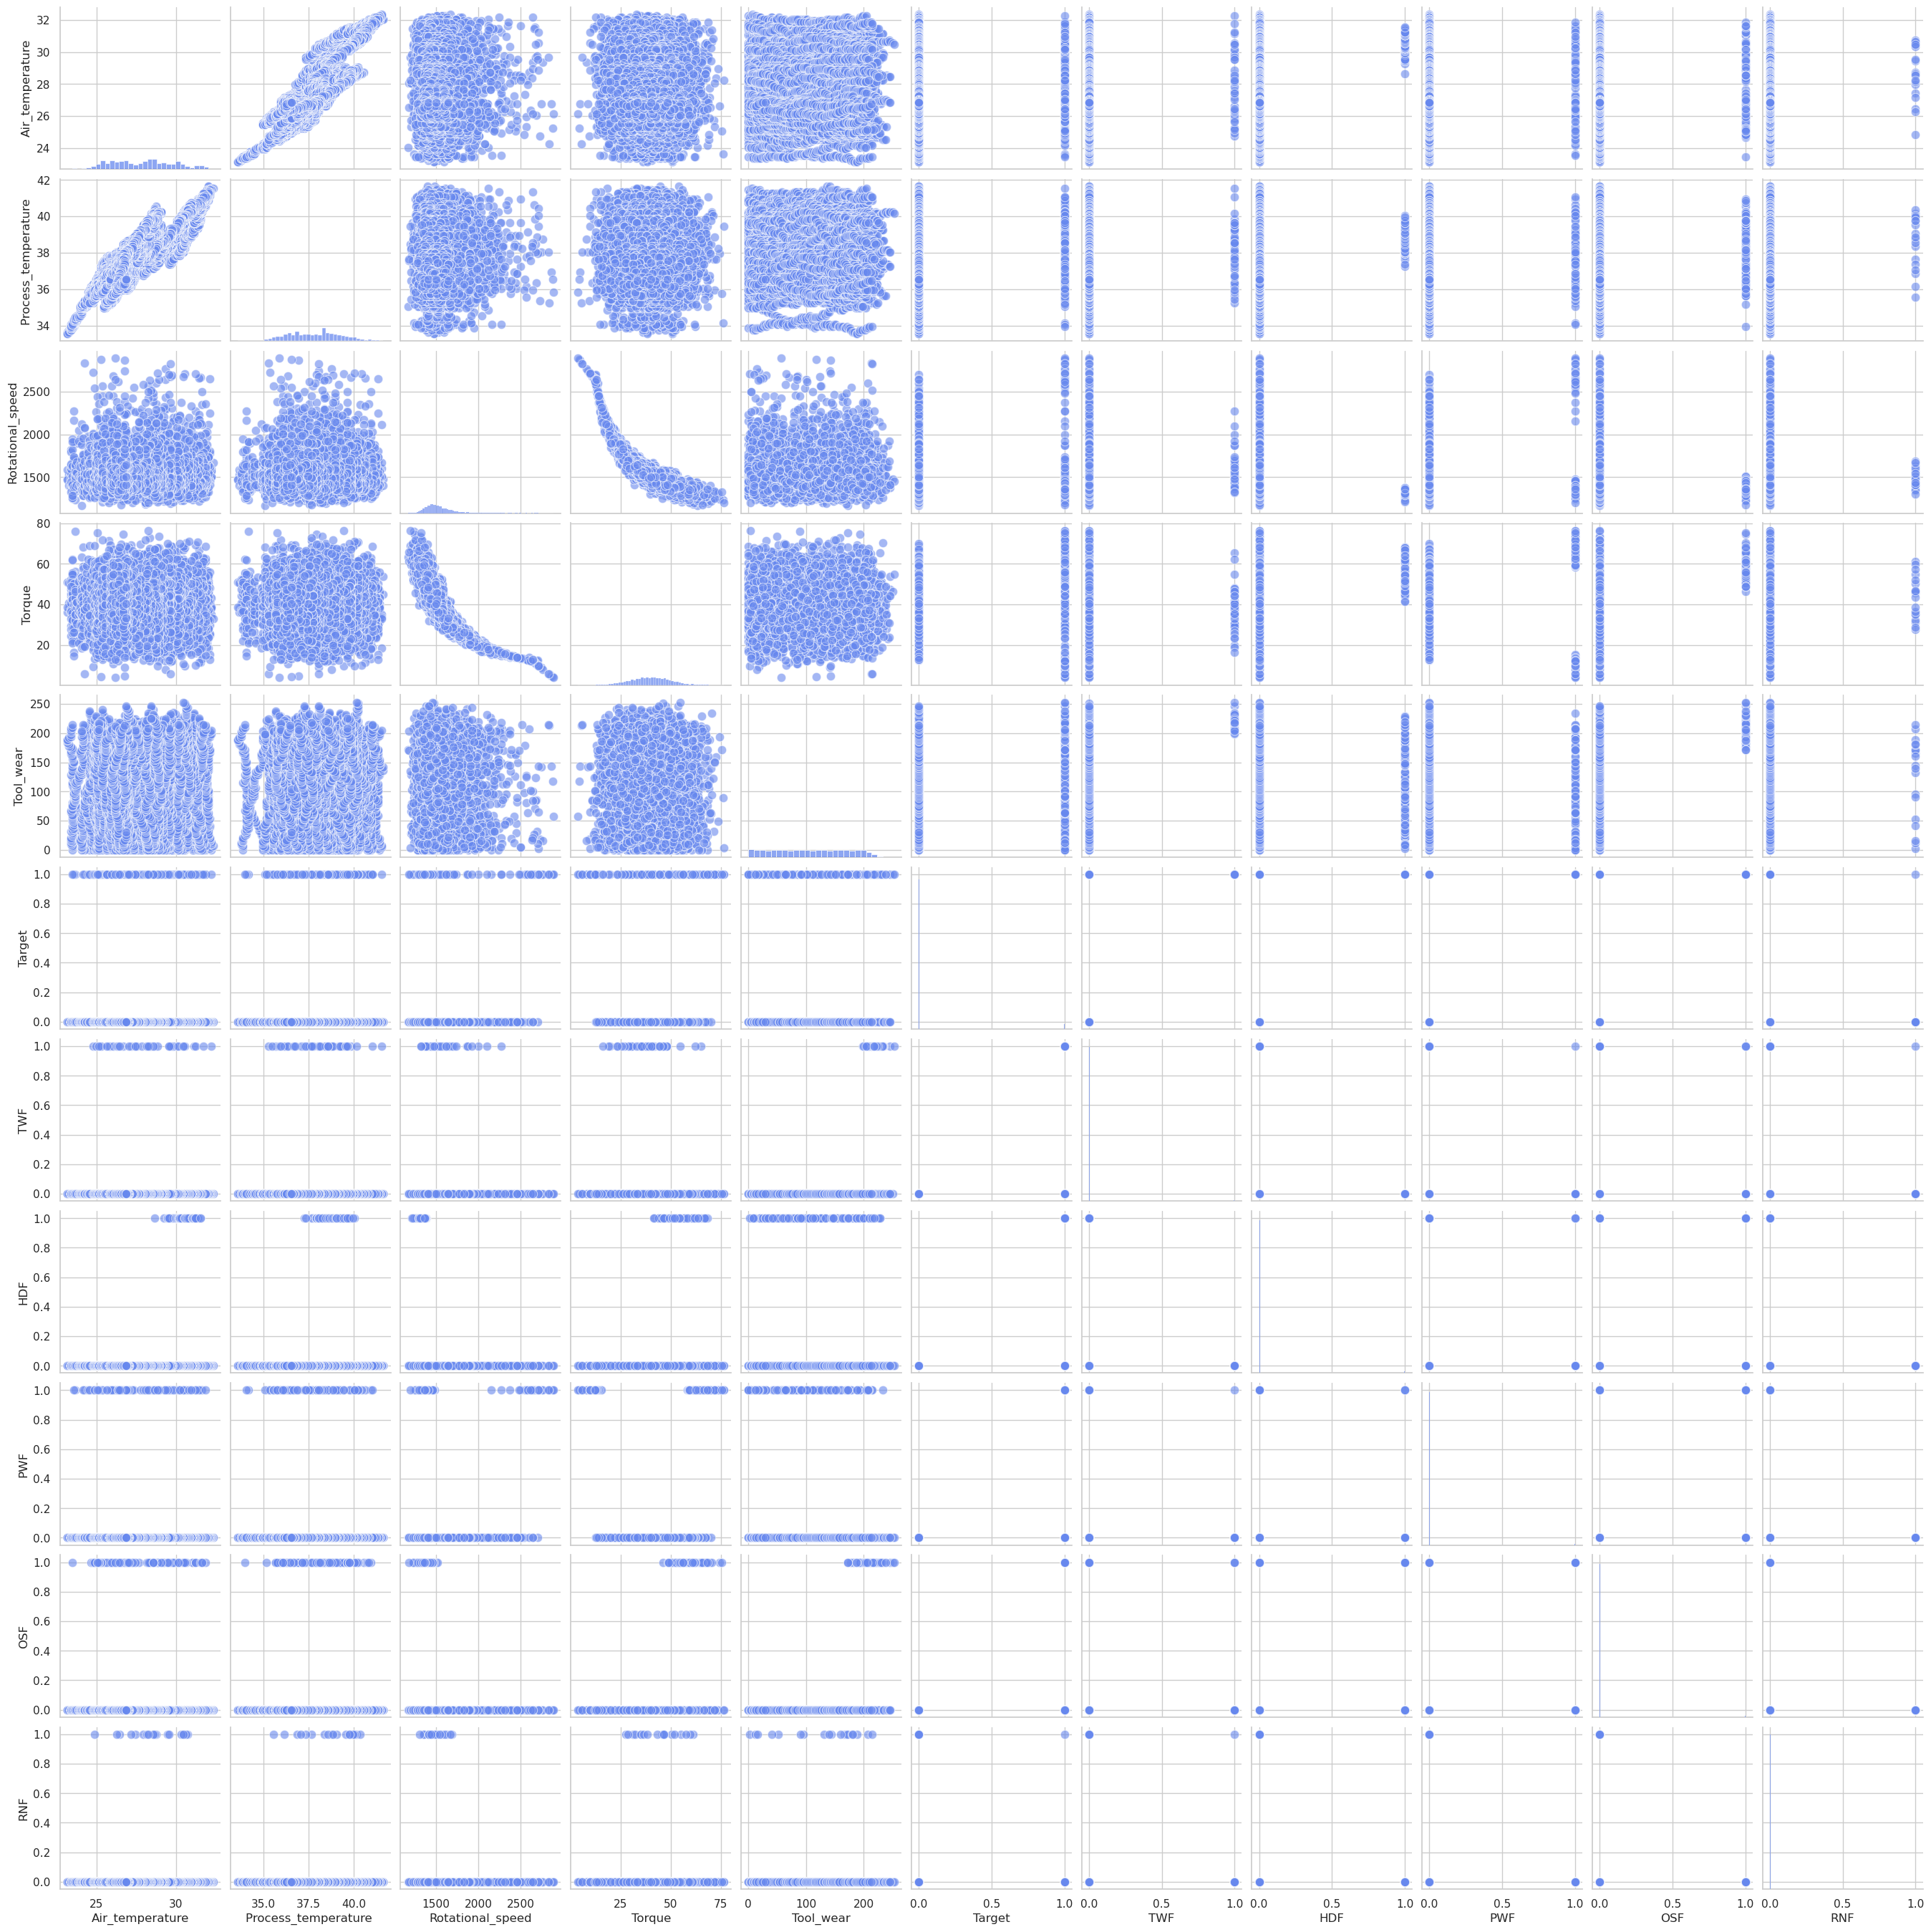

In [59]:
# observe for the float_data
plt.figure(figsize=(25, 25), dpi=250)
sns.set(style="whitegrid")  # Set the plot style
sns.set_palette("coolwarm")    # Set the color palette
sns.pairplot(df.select_dtypes("number"), plot_kws={'alpha': 0.6, 's': 80})

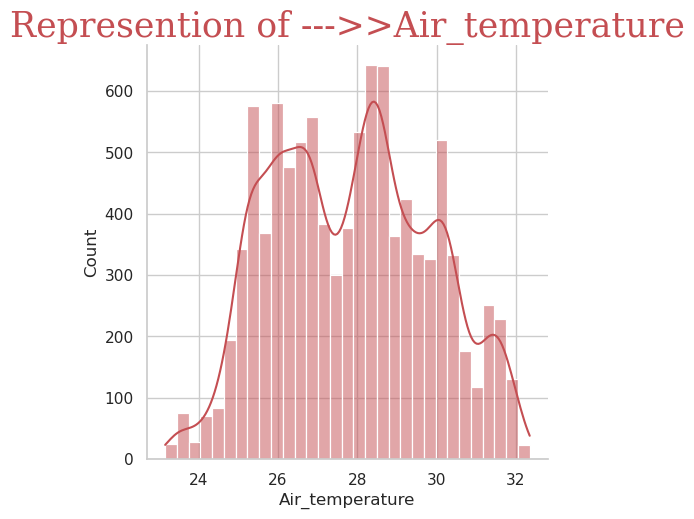

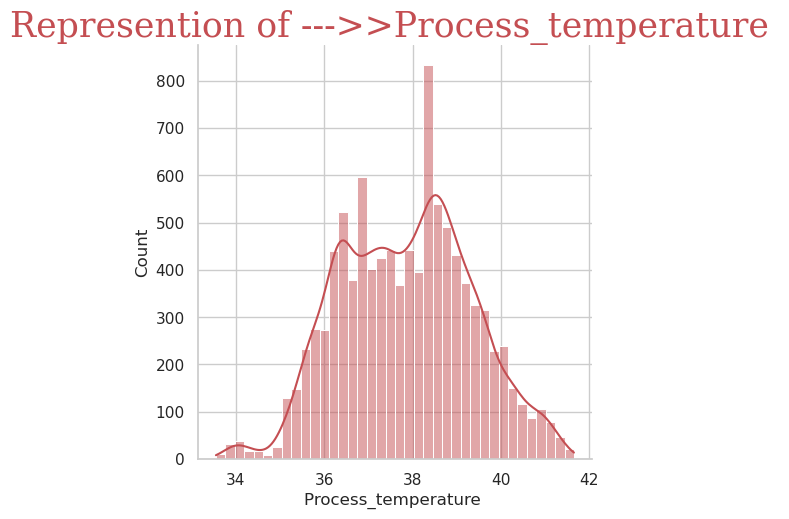

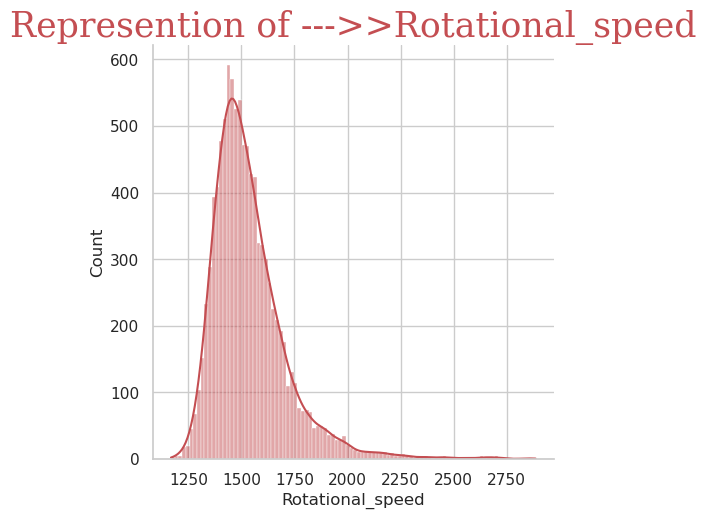

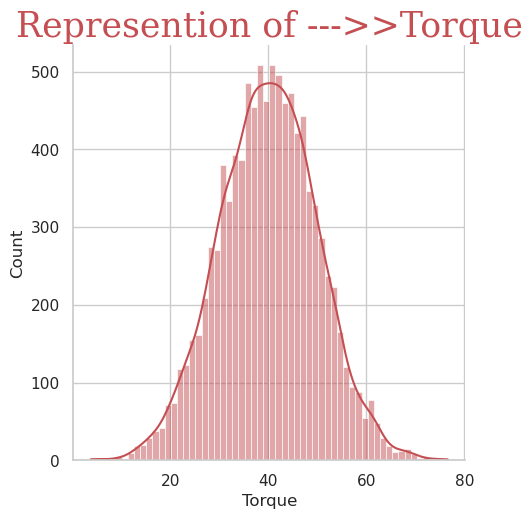

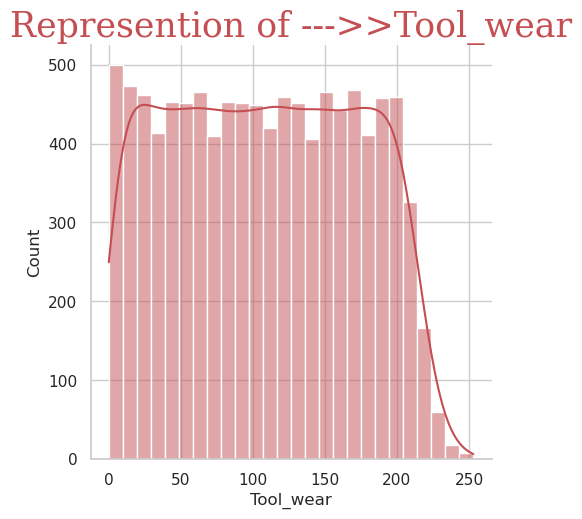

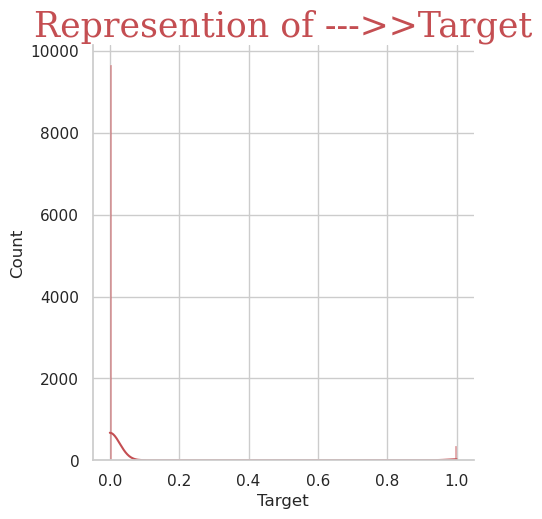

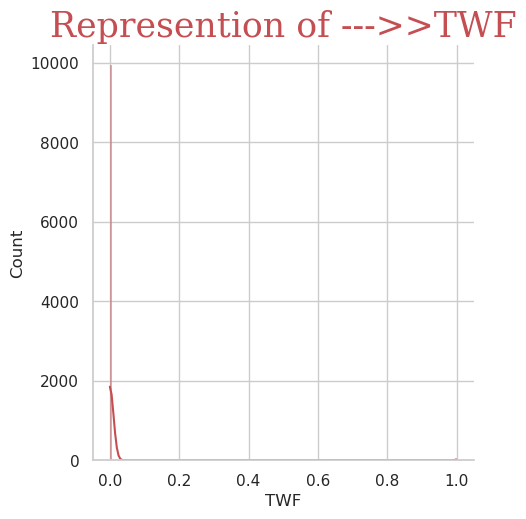

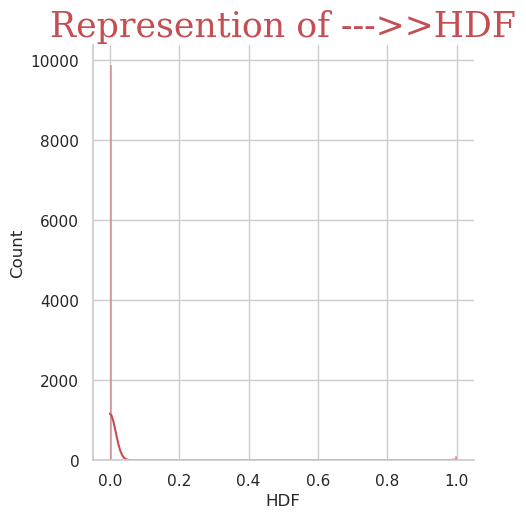

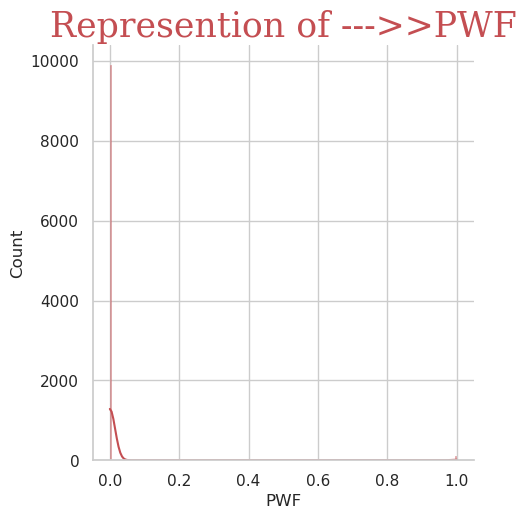

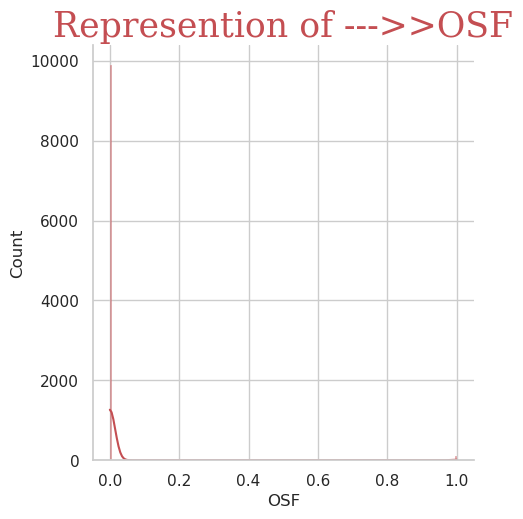

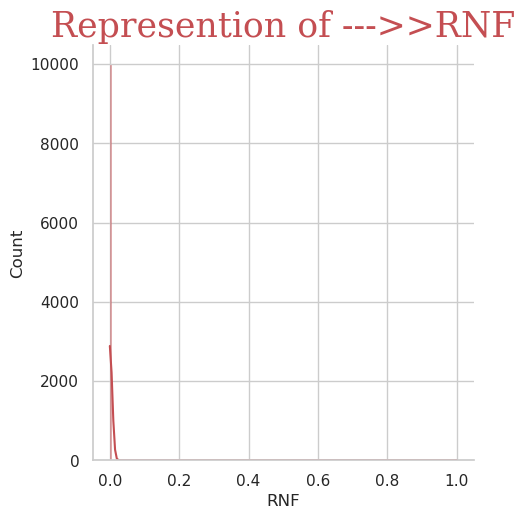

In [61]:
for col in df.select_dtypes("number").columns:
    sns.displot(df[col],kde=True,color="r",label=col)
    sns.set(style="whitegrid")  # Set the plot style
    sns.set_palette("coolwarm")    # Set the color palette
    plt.title("Represention of --->>"+col,fontdict=f1)

In [62]:
df.columns

Index(['Type', 'Air_temperature', 'Process_temperature ', 'Rotational_speed',
       'Torque', 'Tool_wear', 'Target', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')

In [63]:
# whats the affect wheather on Type ?

x = df["Type"]
y1 =df["Air_temperature"]
y2 = df["Torque"]
y3=df["Rotational_speed"]

    
fig = go.Figure(data=[
        go.Bar(name='Air_temperature', x=x, y=y1,marker_color="blue"),
        go.Bar(name='Torque', x=x, y=y2,marker_color="red"),
        go.Bar(name='Rotational_speed',x=x,y=y3,marker_color="yellow")
    ])
    
fig.update_layout(barmode='group',
                      title='Type . vs Air_temperature & Torque & Rotational_speed ',
                      legend_title="Effects",
                      width=800,  
                      height=600 ,       
                      xaxis_title="Type",
                      yaxis_title="Frequency",
                      xaxis_tickangle=-45,
                      yaxis_tickangle=45
    ) 
    
fig.show()


## Important :







<div style="border: 5px solid yellow; padding: 10px; background-color: #F5F5F5; color: black; border-radius: 30px 45px 30px 45px;">

<p> &bull; we will get ride from Failure_Type </p> 

<p>&bull;There are two Targe:
Do not make the mistake of using one of them as feature, as it will lead to leakage.  </p>
</div>

In [65]:
df.columns

Index(['Type', 'Air_temperature', 'Process_temperature ', 'Rotational_speed',
       'Torque', 'Tool_wear', 'Target', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')

In [64]:
df=df.drop("Failure_Type",axis=1)
df.columns

KeyError: "['Failure_Type'] not found in axis"

## Feature Selection 

In [66]:
# convert Categorical into Numerical :
# Convert all Categorical columns into Numerical columns :

label_encoder=LabelEncoder()
for col in df.columns:
    df[col]=label_encoder.fit_transform(df[col])
df

,Type,Air_temperature,Process_temperature,Rotational_speed,Torque,Tool_wear,Target,TWF,HDF,PWF,OSF,RNF
0,2,28,29,325,313,0,0,0,0,0,0,0
1,1,29,30,182,348,2,0,0,0,0,0,0
2,1,28,28,272,379,4,0,0,0,0,0,0
3,1,29,29,207,280,6,0,0,0,0,0,0
4,1,29,30,182,285,8,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2,35,27,378,180,13,0,0,0,0,0,0
9996,0,36,27,406,203,16,0,0,0,0,0,0
9997,2,37,29,419,219,21,0,0,0,0,0,0
9998,0,37,30,182,370,24,0,0,0,0,0,0


In [67]:
# selecting numerical features :
numerical_features = df.select_dtypes(include=['number'])

scaler = MinMaxScaler()
scaled_numerical_features = scaler.fit_transform(numerical_features)

# Create a DataFrame from the scaled numerical features
scaled_numerical_df = pd.DataFrame(scaled_numerical_features, columns=numerical_features.columns)

scaled_numerical_df

,Type,Air_temperature,Process_temperature,Rotational_speed,Torque,Tool_wear,Target,TWF,HDF,PWF,OSF,RNF
0,1.0,0.304348,0.358025,0.345745,0.543403,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,0.5,0.315217,0.370370,0.193617,0.604167,0.008163,0.0,0.0,0.0,0.0,0.0,0.0
2,0.5,0.304348,0.345679,0.289362,0.657986,0.016327,0.0,0.0,0.0,0.0,0.0,0.0
3,0.5,0.315217,0.358025,0.220213,0.486111,0.024490,0.0,0.0,0.0,0.0,0.0,0.0
4,0.5,0.315217,0.370370,0.193617,0.494792,0.032653,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1.0,0.380435,0.333333,0.402128,0.312500,0.053061,0.0,0.0,0.0,0.0,0.0,0.0
9996,0.0,0.391304,0.333333,0.431915,0.352431,0.065306,0.0,0.0,0.0,0.0,0.0,0.0
9997,1.0,0.402174,0.358025,0.445745,0.380208,0.085714,0.0,0.0,0.0,0.0,0.0,0.0
9998,0.0,0.402174,0.370370,0.193617,0.642361,0.097959,0.0,0.0,0.0,0.0,0.0,0.0


## Split Data for Classification :


<div style="border: 5px solid yellow; padding: 10px; background-color: #F5F5F5; color: black; border-radius: 30px 45px 30px 45px;">

<p> &bull; i split data into x_class & y_class </p> 

<p> &bull; x_class : refer into all Data Except Target (Failure or Not) </p> 

<p> &bull; y_class : refer into Target (Target)</p> 

<p> &bull; then , iused train_test_split method to divide data into test , train</p> 
</div>


In [68]:
# split the data int train & test :

x_class,y_clss=make_classification(n_samples=100,random_state=42)

x_class=scaled_numerical_df.drop(columns="Target",axis=1)
y_class=scaled_numerical_df["Target"]

In [69]:
### train split of the Data
x_train,x_test,y_train,y_test=train_test_split(x_class,y_class,test_size=0.3,random_state=42)
print("x_train shape : ",x_train.shape)
print("x_test shape : ",x_test.shape)
print("y_train shape : ",y_train.shape)
print("y_test shape : ",y_test.shape)

x_train shape :  (7000, 11)
x_test shape :  (3000, 11)
y_train shape :  (7000,)
y_test shape :  (3000,)


## Bulding Classification Models (Traditional_models) :

<div style="border: 2px solid yellow; padding: 10px; background-color: #F5F5F5; color: black; border-radius: 30px 45px 30px 45px;">



<p> &bull; <span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Verdana; font-size:28px; color:#FBFAFC; ">LogisticRegression 📊📈</span>  </p> 

<p> &bull; <span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Verdana; font-size:28px; color:#FBFAFC; ">Decision Tree Classifier 🎄</span>  </p> 

<p> &bull;<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Verdana; font-size:28px; color:#FBFAFC; ">SVM 📚</span>  </p> 

<p> &bull; <span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Verdana; font-size:28px; color:#FBFAFC; ">Random Forest Classifier 🎄🎄🎄</span>  </p>

<p> &bull; <span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Verdana; font-size:28px; color:#FBFAFC; ">GradientBoostingClassifier 🌲🚀</span> </p>


</div>



In [70]:
## Define All Models that i will use it :

gridsearch1=GridSearchCV(estimator=RandomForestClassifier(),             # the model used
                        param_grid={"n_estimators":[50,100,160],         # Number of Decision Trees at each state
                        "max_depth":[50,120,180],                        # Number of maximum depth at each state
                        "max_features":[2,3,6]} ,                        # Number of features at naximum in your data
                         cv=3,
                         return_train_score=False,
                         scoring='f1')


gridsearch2=GridSearchCV(estimator=GradientBoostingClassifier(),
                        param_grid={"n_estimators":[50,100,120],
                        "max_depth":[50,120,200],
                        "max_features":[3,5,6]},
                         cv=3,
                         return_train_score=False,
                         scoring='f1')

models={
    "LogisticRegression":LogisticRegression(),
    "DecisionTreeClassifier":DecisionTreeClassifier(max_depth=5,max_features=6,random_state=42),
    "RandomForestClassifier":gridsearch1,
    "svm":svm.SVC(random_state=42,kernel='poly'),
    "GradientBoostingClassifier":gridsearch2}

<span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Verdana; font-size:28px; color:#FBFAFC; ">Result 📚</span>

Model: LogisticRegression
Mean Squared Error (MSE): 0.001
acc_train: 99.91%
acc_model: 99.90%
Mean Squared Error train data (MSE): 0.0008571428571428571
Mean Squared Error test data (MSE): 0.001

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2907
         1.0       1.00      0.97      0.98        93

    accuracy                           1.00      3000
   macro avg       1.00      0.98      0.99      3000
weighted avg       1.00      1.00      1.00      3000



Model: DecisionTreeClassifier
Mean Squared Error (MSE): 0.001
acc_train: 99.91%
acc_model: 99.90%
Mean Squared Error train data (MSE): 0.0008571428571428571
Mean Squared Error test data (MSE): 0.001

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2907
         1.0       1.00      0.97      0.98        93

    accuracy                           1.00      3000
   macro av

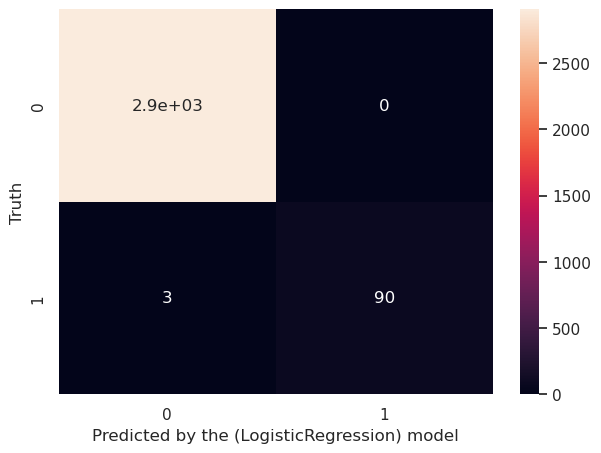

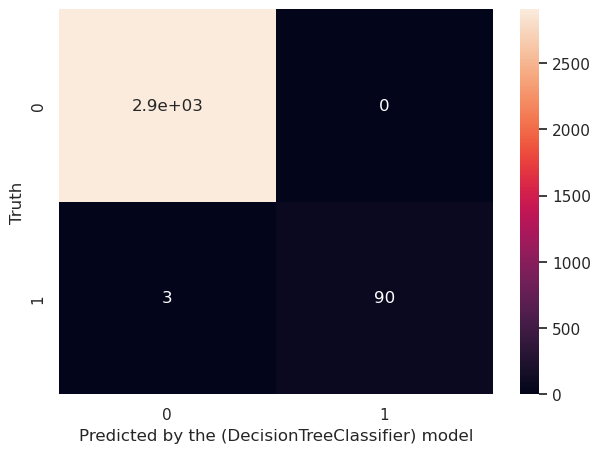

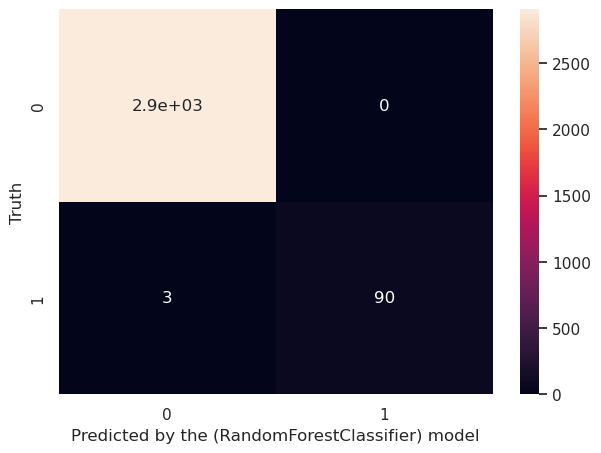

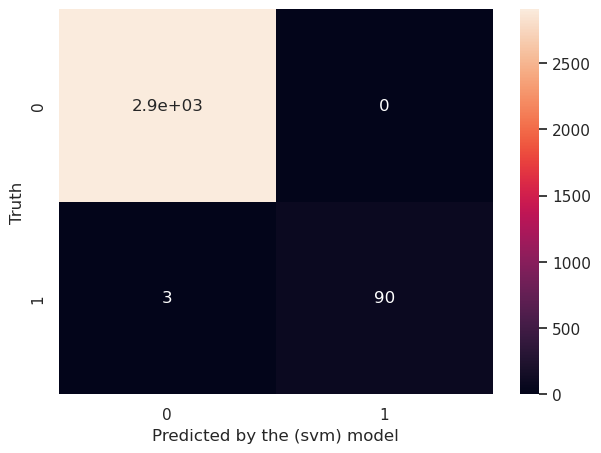

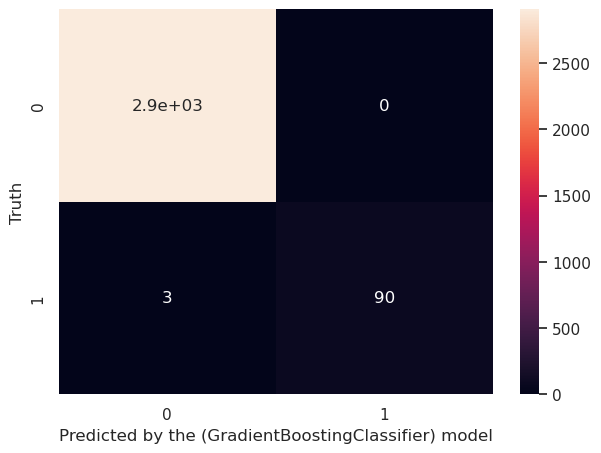

In [71]:
for model_name, model in models.items():
    # Fit the model to the training data
    model.fit(x_train, y_train)
    
    # Make predictions on the test & train data
    y_pred = model.predict(x_test)
    y_train_pred = model.predict(x_train)
    
    # calc acc Score on test & train data :
    acc_train = model.score(x_train, y_train)
    # calc mean square error on train & test data :
    
    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_pred)
    
    
    # Evaluate the model
    mse = metrics.mean_squared_error(y_test, y_pred)
    acc = model.score(x_test,y_test)
    print("="*60)
    
    
    model_evaluation_metrics = {}
    # Calculate confusion matrix and classification report
    cm = confusion_matrix(y_test, y_pred)
    classif_report = classification_report(y_test, y_pred)
    # Storing the results
    model_evaluation_metrics[model_name] = {
        "Confusion Matrix":cm,
        'Classification Report': classif_report
    }
    
    plt.figure(figsize=(7,5))
    sns.heatmap(cm,annot=True)
    plt.xlabel(f"Predicted by the ({model_name}) model")
    plt.ylabel('Truth'),
    
    # Print the evaluation metrics for each model
    
    print(f"Model: {model_name}")
    print(f"Mean Squared Error (MSE): {mse}")
    
    print(f"acc_train: {acc_train*100:0.2f}%")
    print(f"acc_model: {acc*100:0.2f}%")
    
    print(f"Mean Squared Error train data (MSE): {mse_train}")
    print(f"Mean Squared Error test data (MSE): {mse_test}")
    print("\nClassification Report:")
    print(classif_report)
    print("\n" + "="*60 + "\n")
   
    

<p> &bull; <span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Verdana; font-size:28px; color:#FBFAFC; ">  Get feature importances for Decision Tree Classifier 🎄</span>  </p> 

In [72]:

font_properties = {
    'family': 'serif',
    'color': 'green',
    'weight': 'bold',
    'size': 40}

decision_tree_model = models["DecisionTreeClassifier"]
plt.figure(figsize=(95,85),dpi=150)  # Adjust figure size as needed
tree.plot_tree(decision_tree_model, filled=True, feature_names=x_class.columns, node_ids=True, fontsize=42)  # Control node size with fontsize
plt.title("Decision Tree",fontdict=font_properties)
plt.show()


In [73]:
feature_importances1 = decision_tree_model.feature_importances_
feature_names = x_class.columns

# Create a DataFrame to display feature importances
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances1})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
importance_df.style.background_gradient(cmap="Blues")

,Feature,Importance
7,HDF,0.349094
9,OSF,0.284512
8,PWF,0.162361
6,TWF,0.126762
4,Torque,0.077271
0,Type,0.000000
1,Air_temperature,0.000000
2,Process_temperature,0.000000
3,Rotational_speed,0.000000
5,Tool_wear,0.000000


<p> &bull; <span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Verdana; font-size:28px; color:#FBFAFC; ">Random Forest Classifier 🎄🎄🎄</span>  </p>


In [74]:
best_estimator = gridsearch1.best_estimator_
feature_importances2 = best_estimator.feature_importances_
feature_names = x_class.columns

# Create a DataFrame to display feature importances

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances2})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
importance_df.style.background_gradient(cmap="Oranges")

,Feature,Importance
7,HDF,0.278449
9,OSF,0.203663
8,PWF,0.145502
4,Torque,0.106358
6,TWF,0.100016
3,Rotational_speed,0.076550
5,Tool_wear,0.037283
2,Process_temperature,0.025075
1,Air_temperature,0.022231
0,Type,0.004143


<p> &bull; <span class="label label-default" style="background-color:#DC1010; border-radius:12px; font-weight: bold; font-family:Verdana; font-size:28px; color:#FBFAFC; ">GradientBoostingClassifier🌲🚀</span>  </p>

In [75]:
best_estimator = gridsearch2.best_estimator_
feature_importances3 = best_estimator.feature_importances_
feature_names = x_class.columns

# Create a DataFrame to display feature importances

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances3})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
importance_df.style.background_gradient(cmap="Reds")

,Feature,Importance
7,HDF,0.300591
8,PWF,0.207233
9,OSF,0.180681
6,TWF,0.107241
4,Torque,0.072067
3,Rotational_speed,0.044431
5,Tool_wear,0.042462
1,Air_temperature,0.022330
2,Process_temperature,0.019598
0,Type,0.002117
